# ChestXRayAnatomySegmentation baseline

This notebook uses the same demo image as the other segmentation notebook, but runs the new `xrv.baseline_models.chestx_anatomy.UNetResNet50` baseline.

The first section gives a quick look at a few representative anatomy masks. The second section shows all 159 targets twice: once as raw sigmoid probabilities and once after thresholding. The last section shows three color overlays with overlapping anatomy groups.

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import numpy as np
import skimage
import torch
import torchvision
import matplotlib.pyplot as plt
import torchxrayvision as xrv


/Users/ieee8023/.pyenv/versions/3.11.8/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /Users/ieee8023/.pyenv/versions/3.11.8/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:
# Weights are downloaded automatically from the xrv release asset when available.
model = xrv.baseline_models.chestx_anatomy.UNetResNet50()
model


cxas-unet-resnet50

In [4]:
img = skimage.io.imread("../tests/covid-19-pneumonia-58-prior.jpg")
img = xrv.datasets.normalize(img, 255)
img = img.mean(2)[None, ...]

transform = torchvision.transforms.Compose([
    xrv.datasets.XRayCenterCrop(),
    xrv.datasets.XRayResizer(512),
])

img = transform(img)
img = torch.from_numpy(img)


In [5]:
with torch.no_grad():
    pred = model(img)

prob = torch.sigmoid(pred)
mask = prob > 0.5


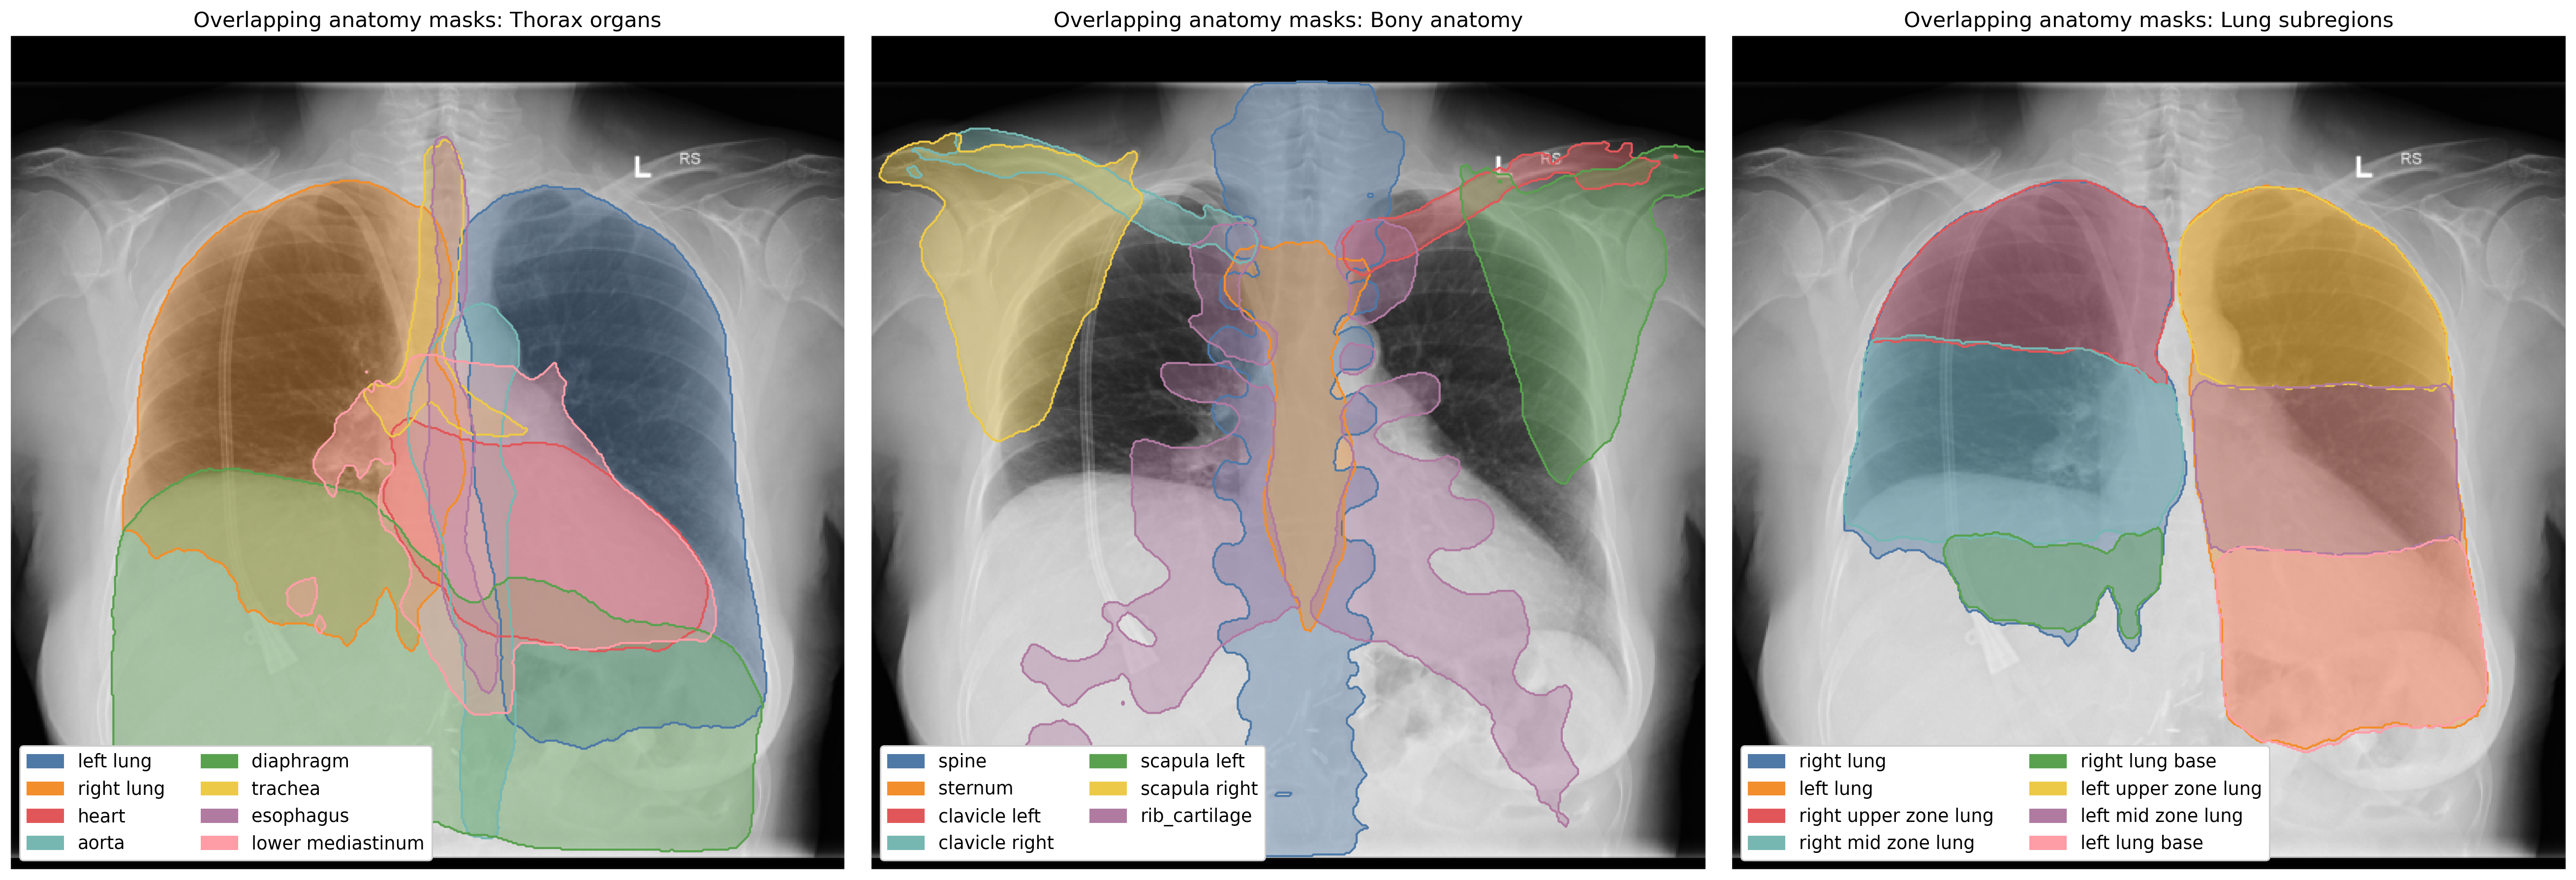

In [12]:
# Color overlays for a few representative anatomy groups.
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

overlay_groups = [
    (
        "Thorax organs",
        ["left lung", "right lung", "heart", "aorta", "diaphragm", "trachea", "esophagus", "lower mediastinum"],
        ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F", "#EDC948", "#B07AA1", "#FF9DA7"],
    ),
    (
        "Bony anatomy",
        ["spine", "sternum", "clavicle left", "clavicle right", "scapula left", "scapula right", "rib_cartilage"],
        ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F", "#EDC948", "#B07AA1"],
    ),
    (
        "Lung subregions",
        ["right lung", "left lung", "right upper zone lung", "right mid zone lung", "right lung base", "left upper zone lung", "left mid zone lung", "left lung base"],
        ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F", "#EDC948", "#B07AA1", "#FF9DA7"],
    ),
]

def show_color_overlays(ax, target_names, colors, title):
    ax.imshow(img[0].detach().cpu().numpy(), cmap="gray")
    legend_handles = []

    for name, color in zip(target_names, colors):
        idx = model.targets.index(name)
        layer = mask[0, idx].detach().cpu().numpy().astype(bool)
        if not layer.any():
            continue

        overlay = np.ma.masked_where(~layer, layer)
        ax.imshow(
            overlay,
            cmap=ListedColormap([color]),
            interpolation="nearest",
            alpha=0.38,
        )
        ax.contour(layer.astype(float), levels=[0.5], colors=[color], linewidths=1.4)
        legend_handles.append(Patch(facecolor=color, edgecolor=color, label=name))

    ax.set_title(title, fontsize=14)
    ax.axis("off")
    if legend_handles:
        ax.legend(
            handles=legend_handles,
            loc="lower left",
            fontsize=12,
            framealpha=1,
            ncol=2,
        )

fig, axes = plt.subplots(1, 3, figsize=(24, 8), dpi=220)
for ax, (title, target_names, colors) in zip(axes, overlay_groups):
    show_color_overlays(ax, target_names, colors, f"Overlapping anatomy masks: {title}")

plt.tight_layout()


In [7]:
def show_all_targets(values, title, cmap, vmin=None, vmax=None, threshold=False, max_targets_per_figure=24):
    n_targets = len(model.targets)
    ncols = 4

    for fig_idx, start in enumerate(range(0, n_targets, max_targets_per_figure), start=1):
        stop = min(start + max_targets_per_figure, n_targets)
        chunk_targets = model.targets[start:stop]
        nrows = int(np.ceil(len(chunk_targets) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 2.5), dpi=220)
        axes = np.atleast_1d(axes).ravel()

        for i, name in enumerate(chunk_targets):
            ax = axes[i]
            panel = values[start + i].detach().cpu()
            if threshold:
                panel = panel.float()
            ax.imshow(panel, cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_title(name, fontsize=6)
            ax.axis("off")

        for ax in axes[len(chunk_targets):]:
            ax.axis("off")

        fig.suptitle(f"{title} ({fig_idx})", y=1.002, fontsize=14)
        plt.tight_layout()


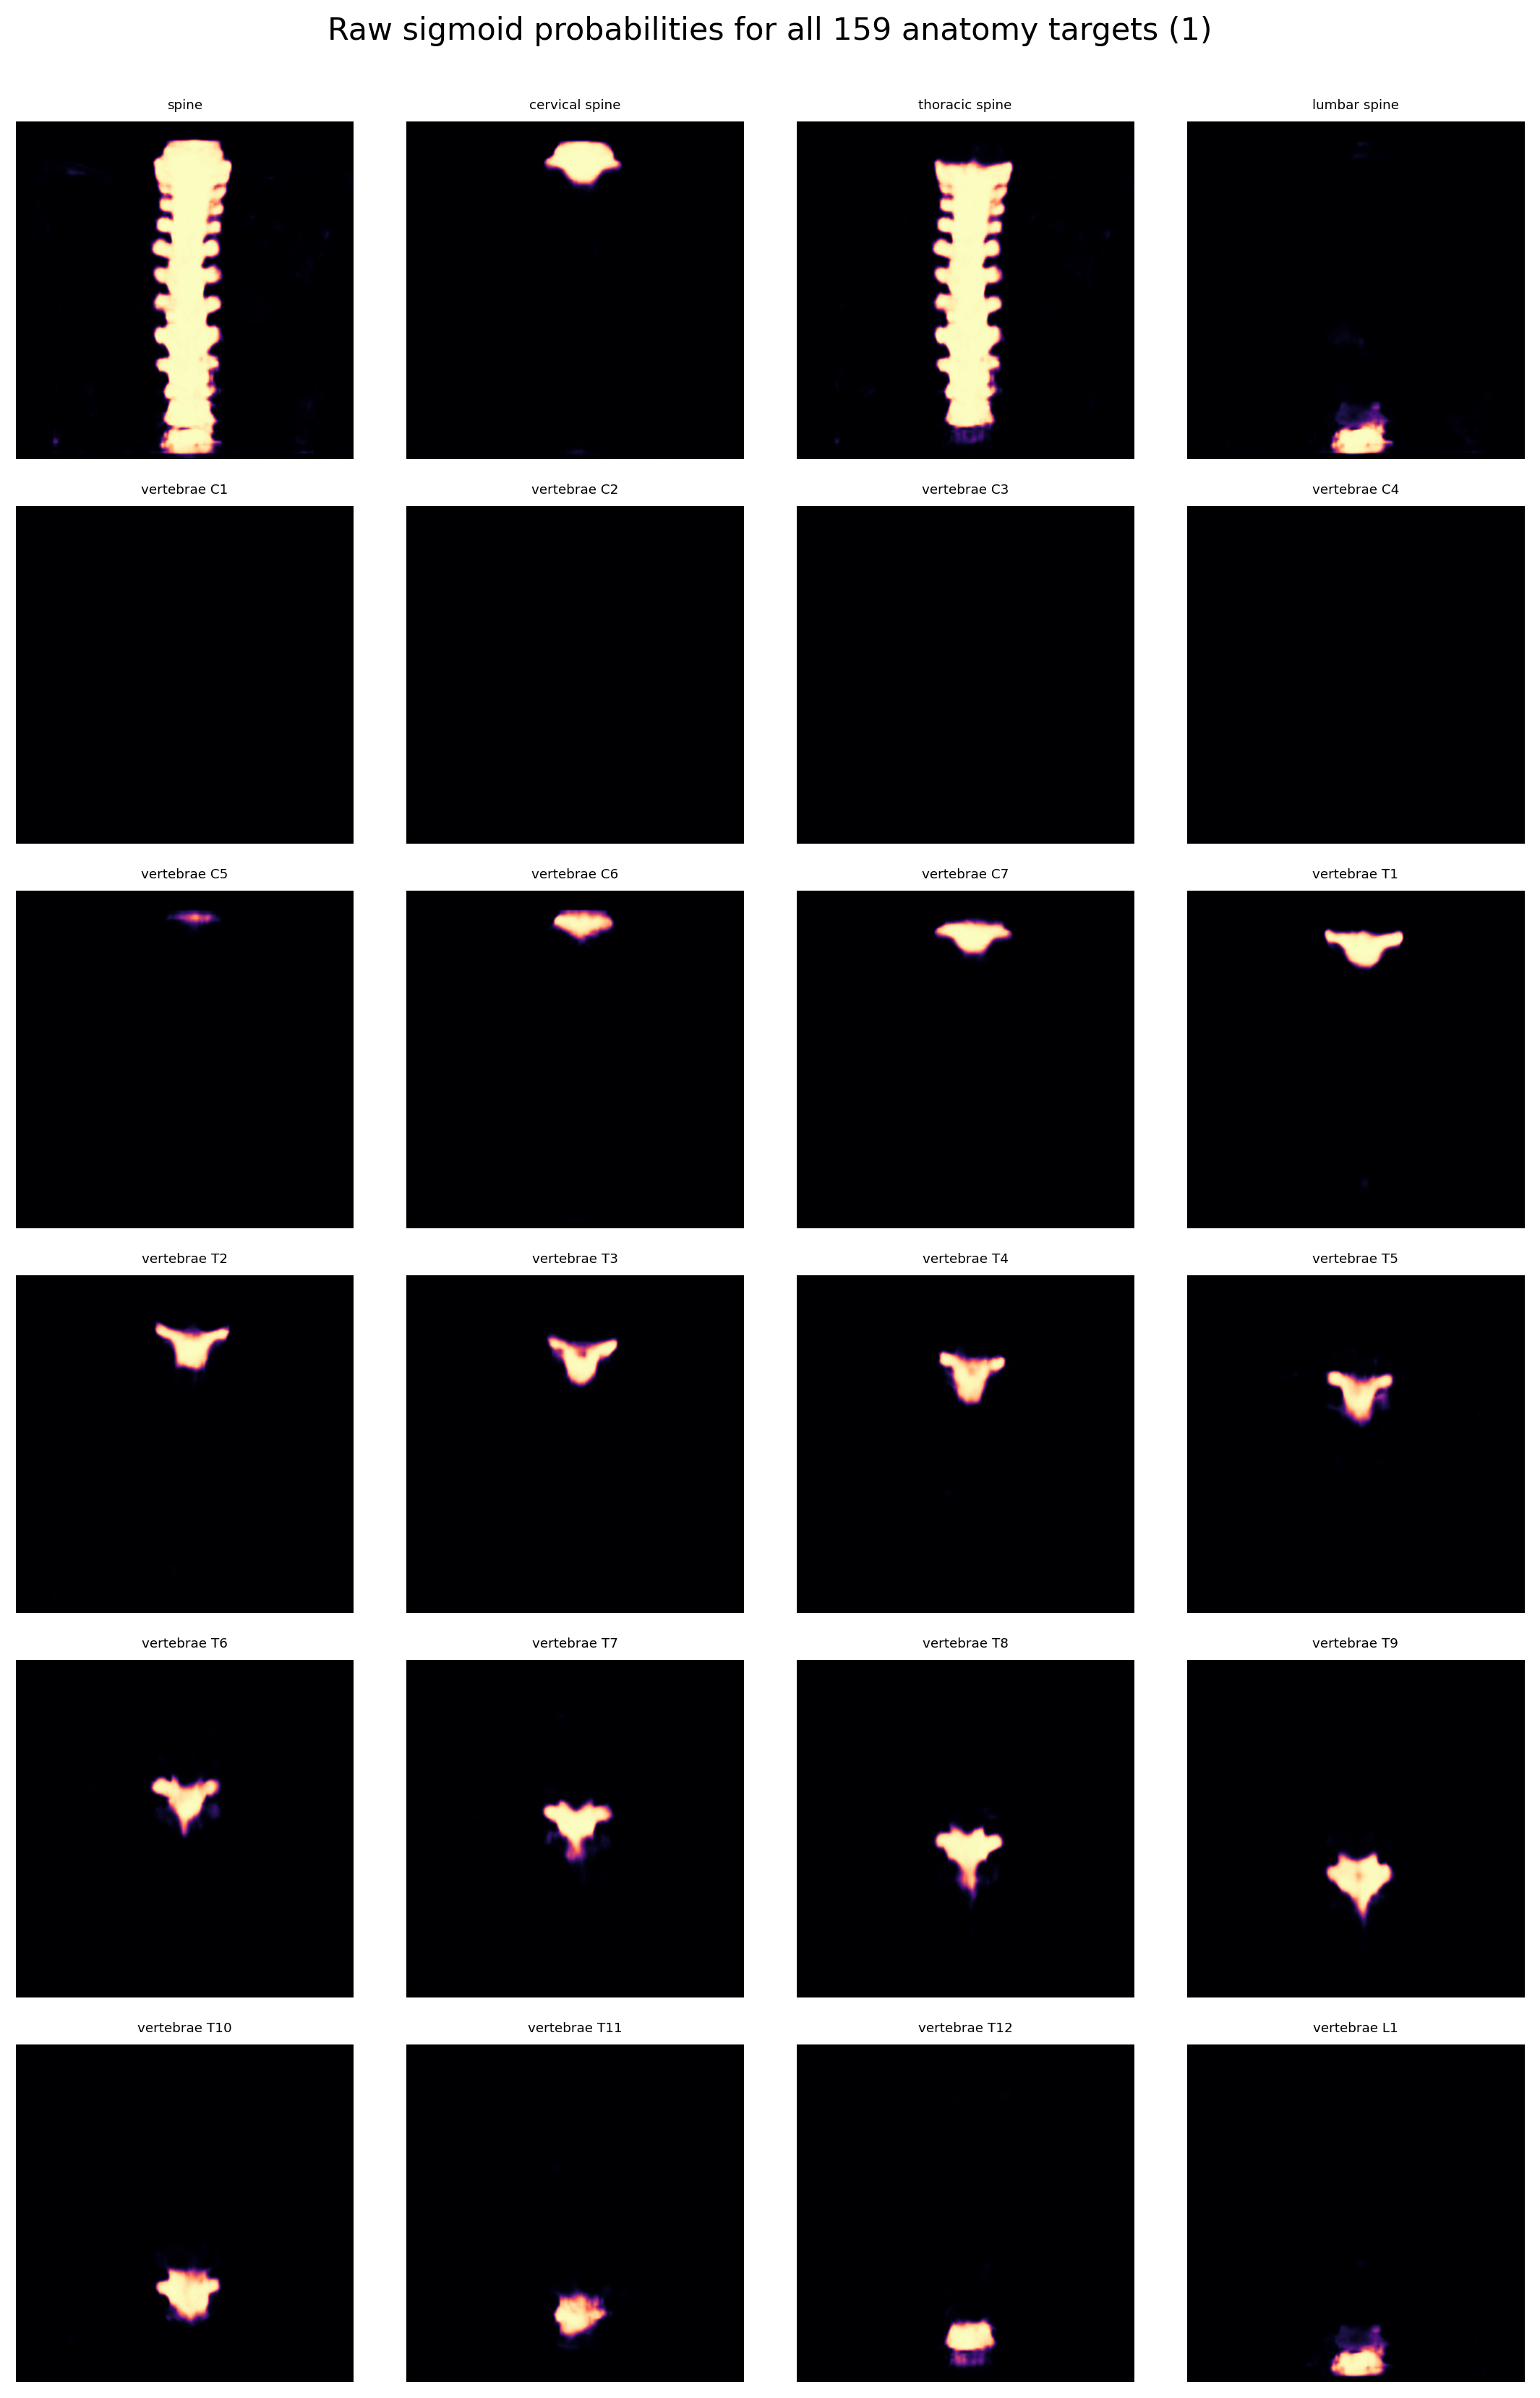

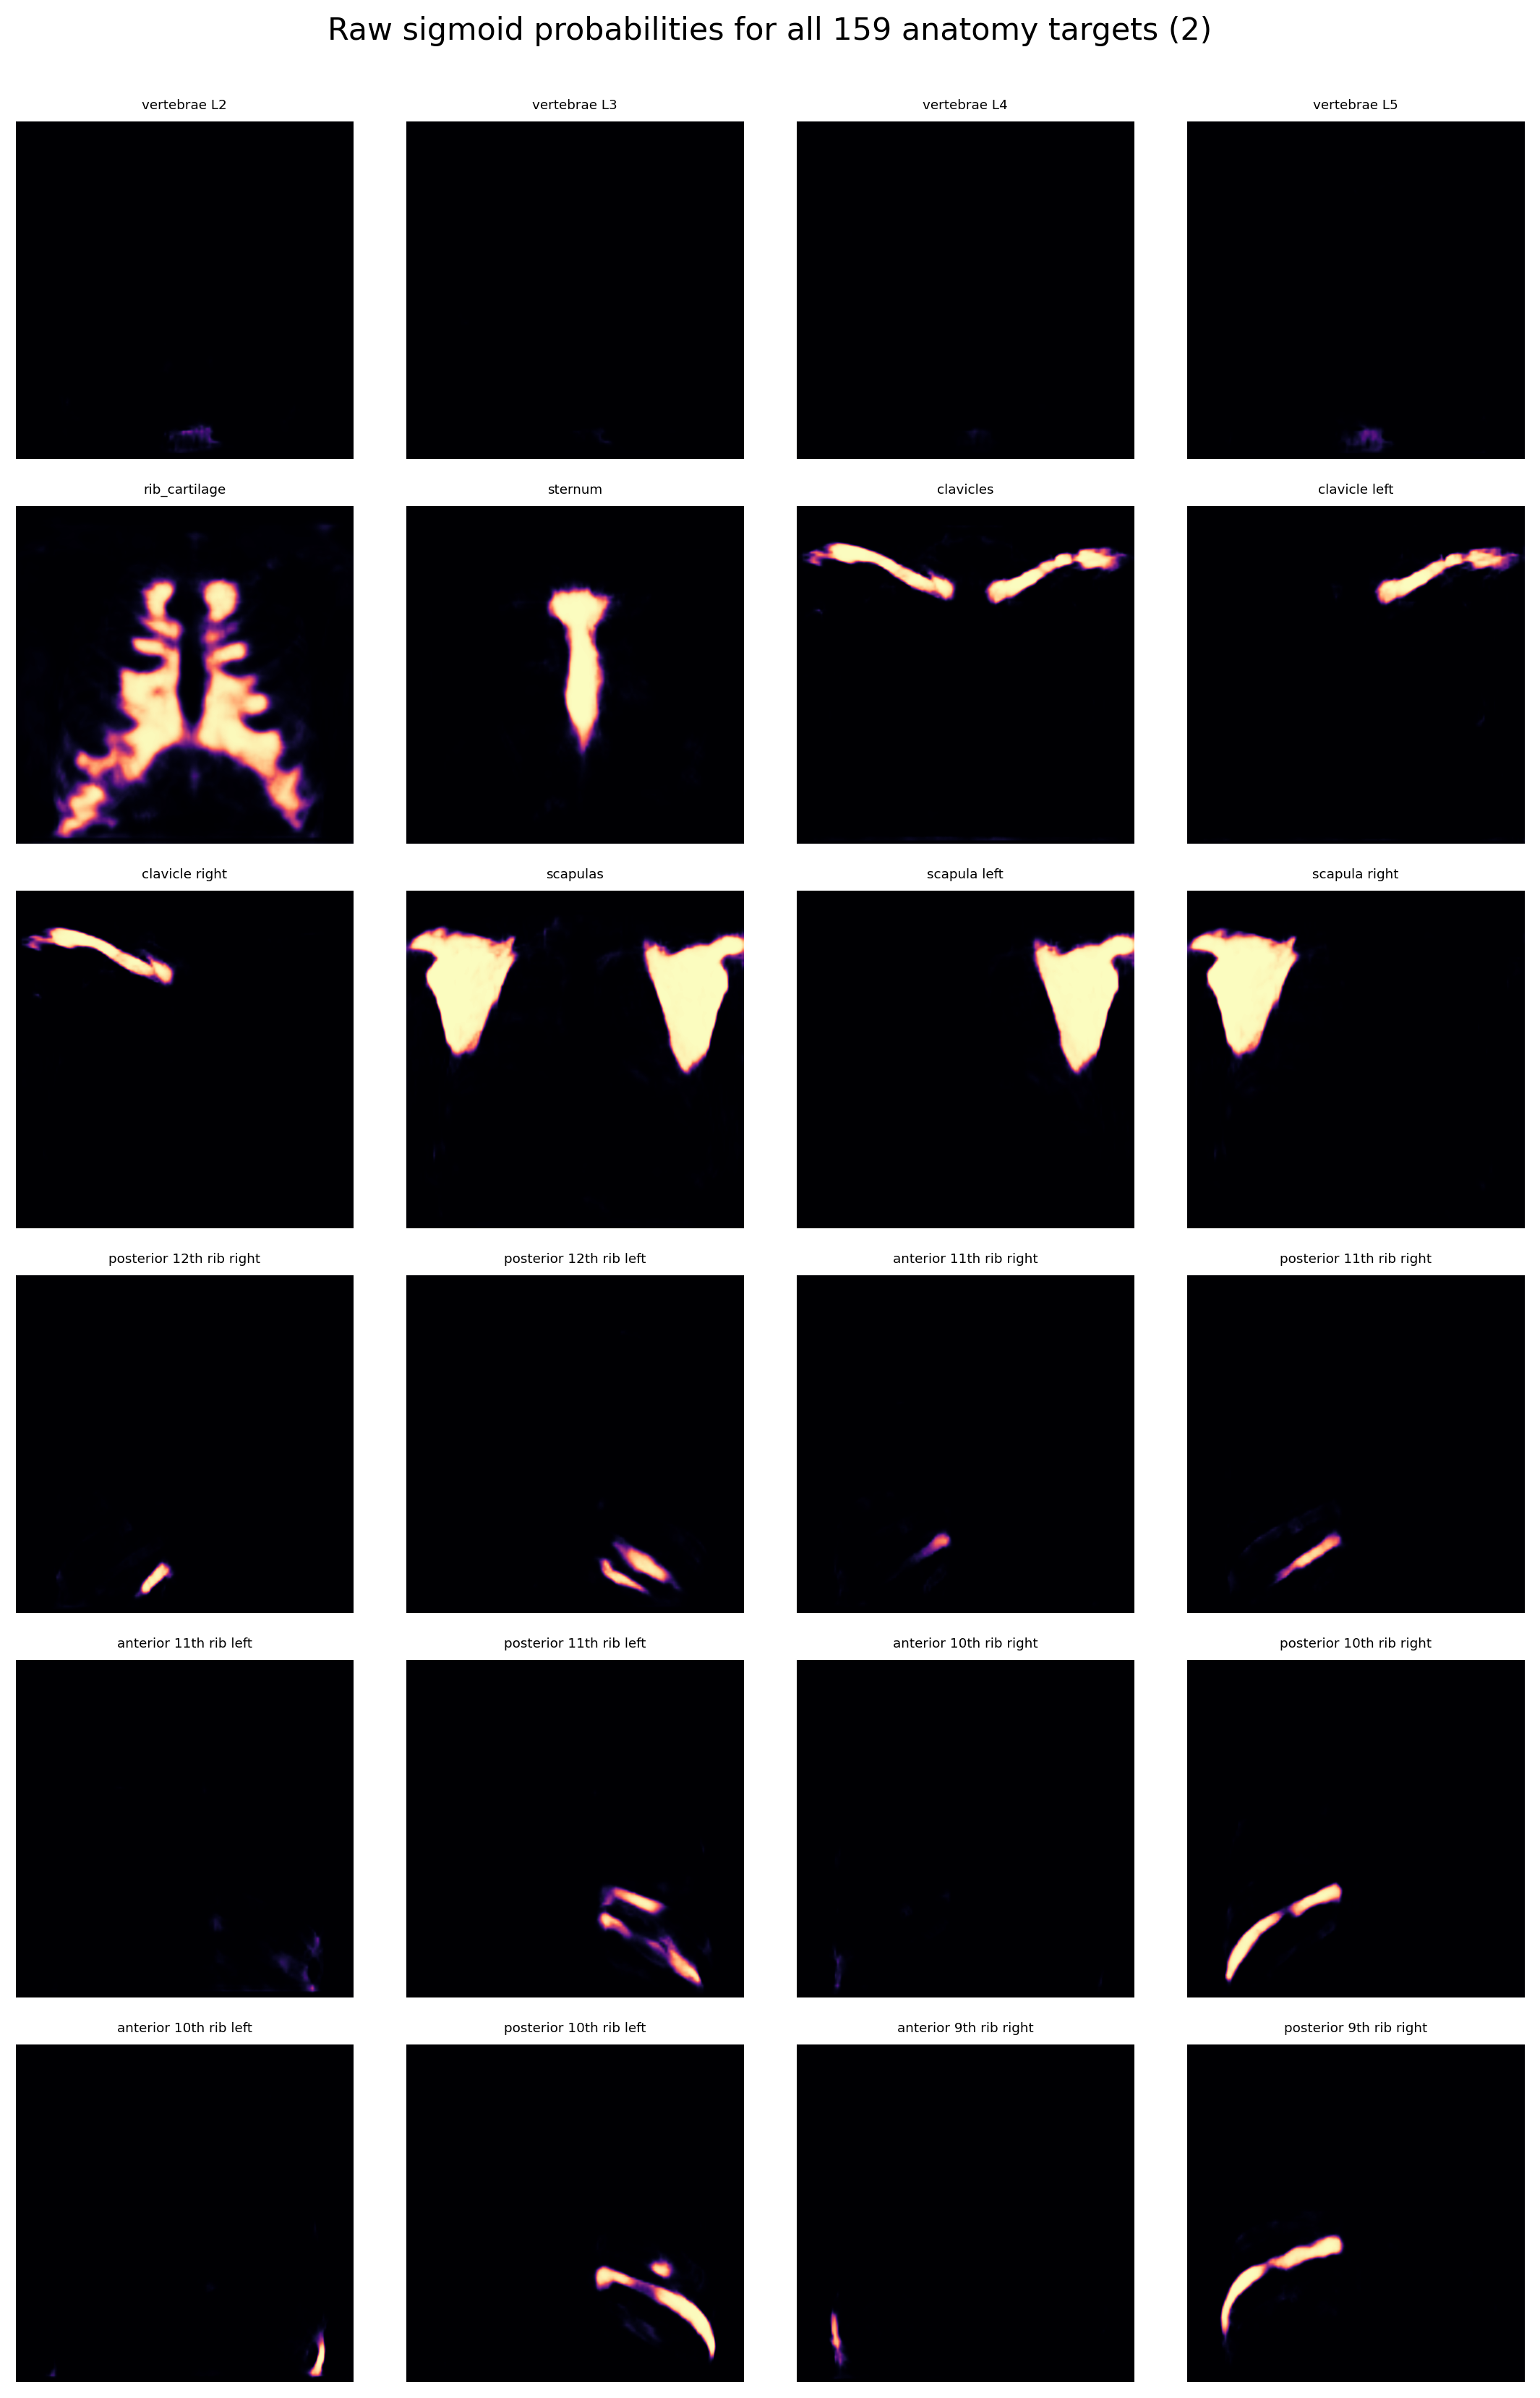

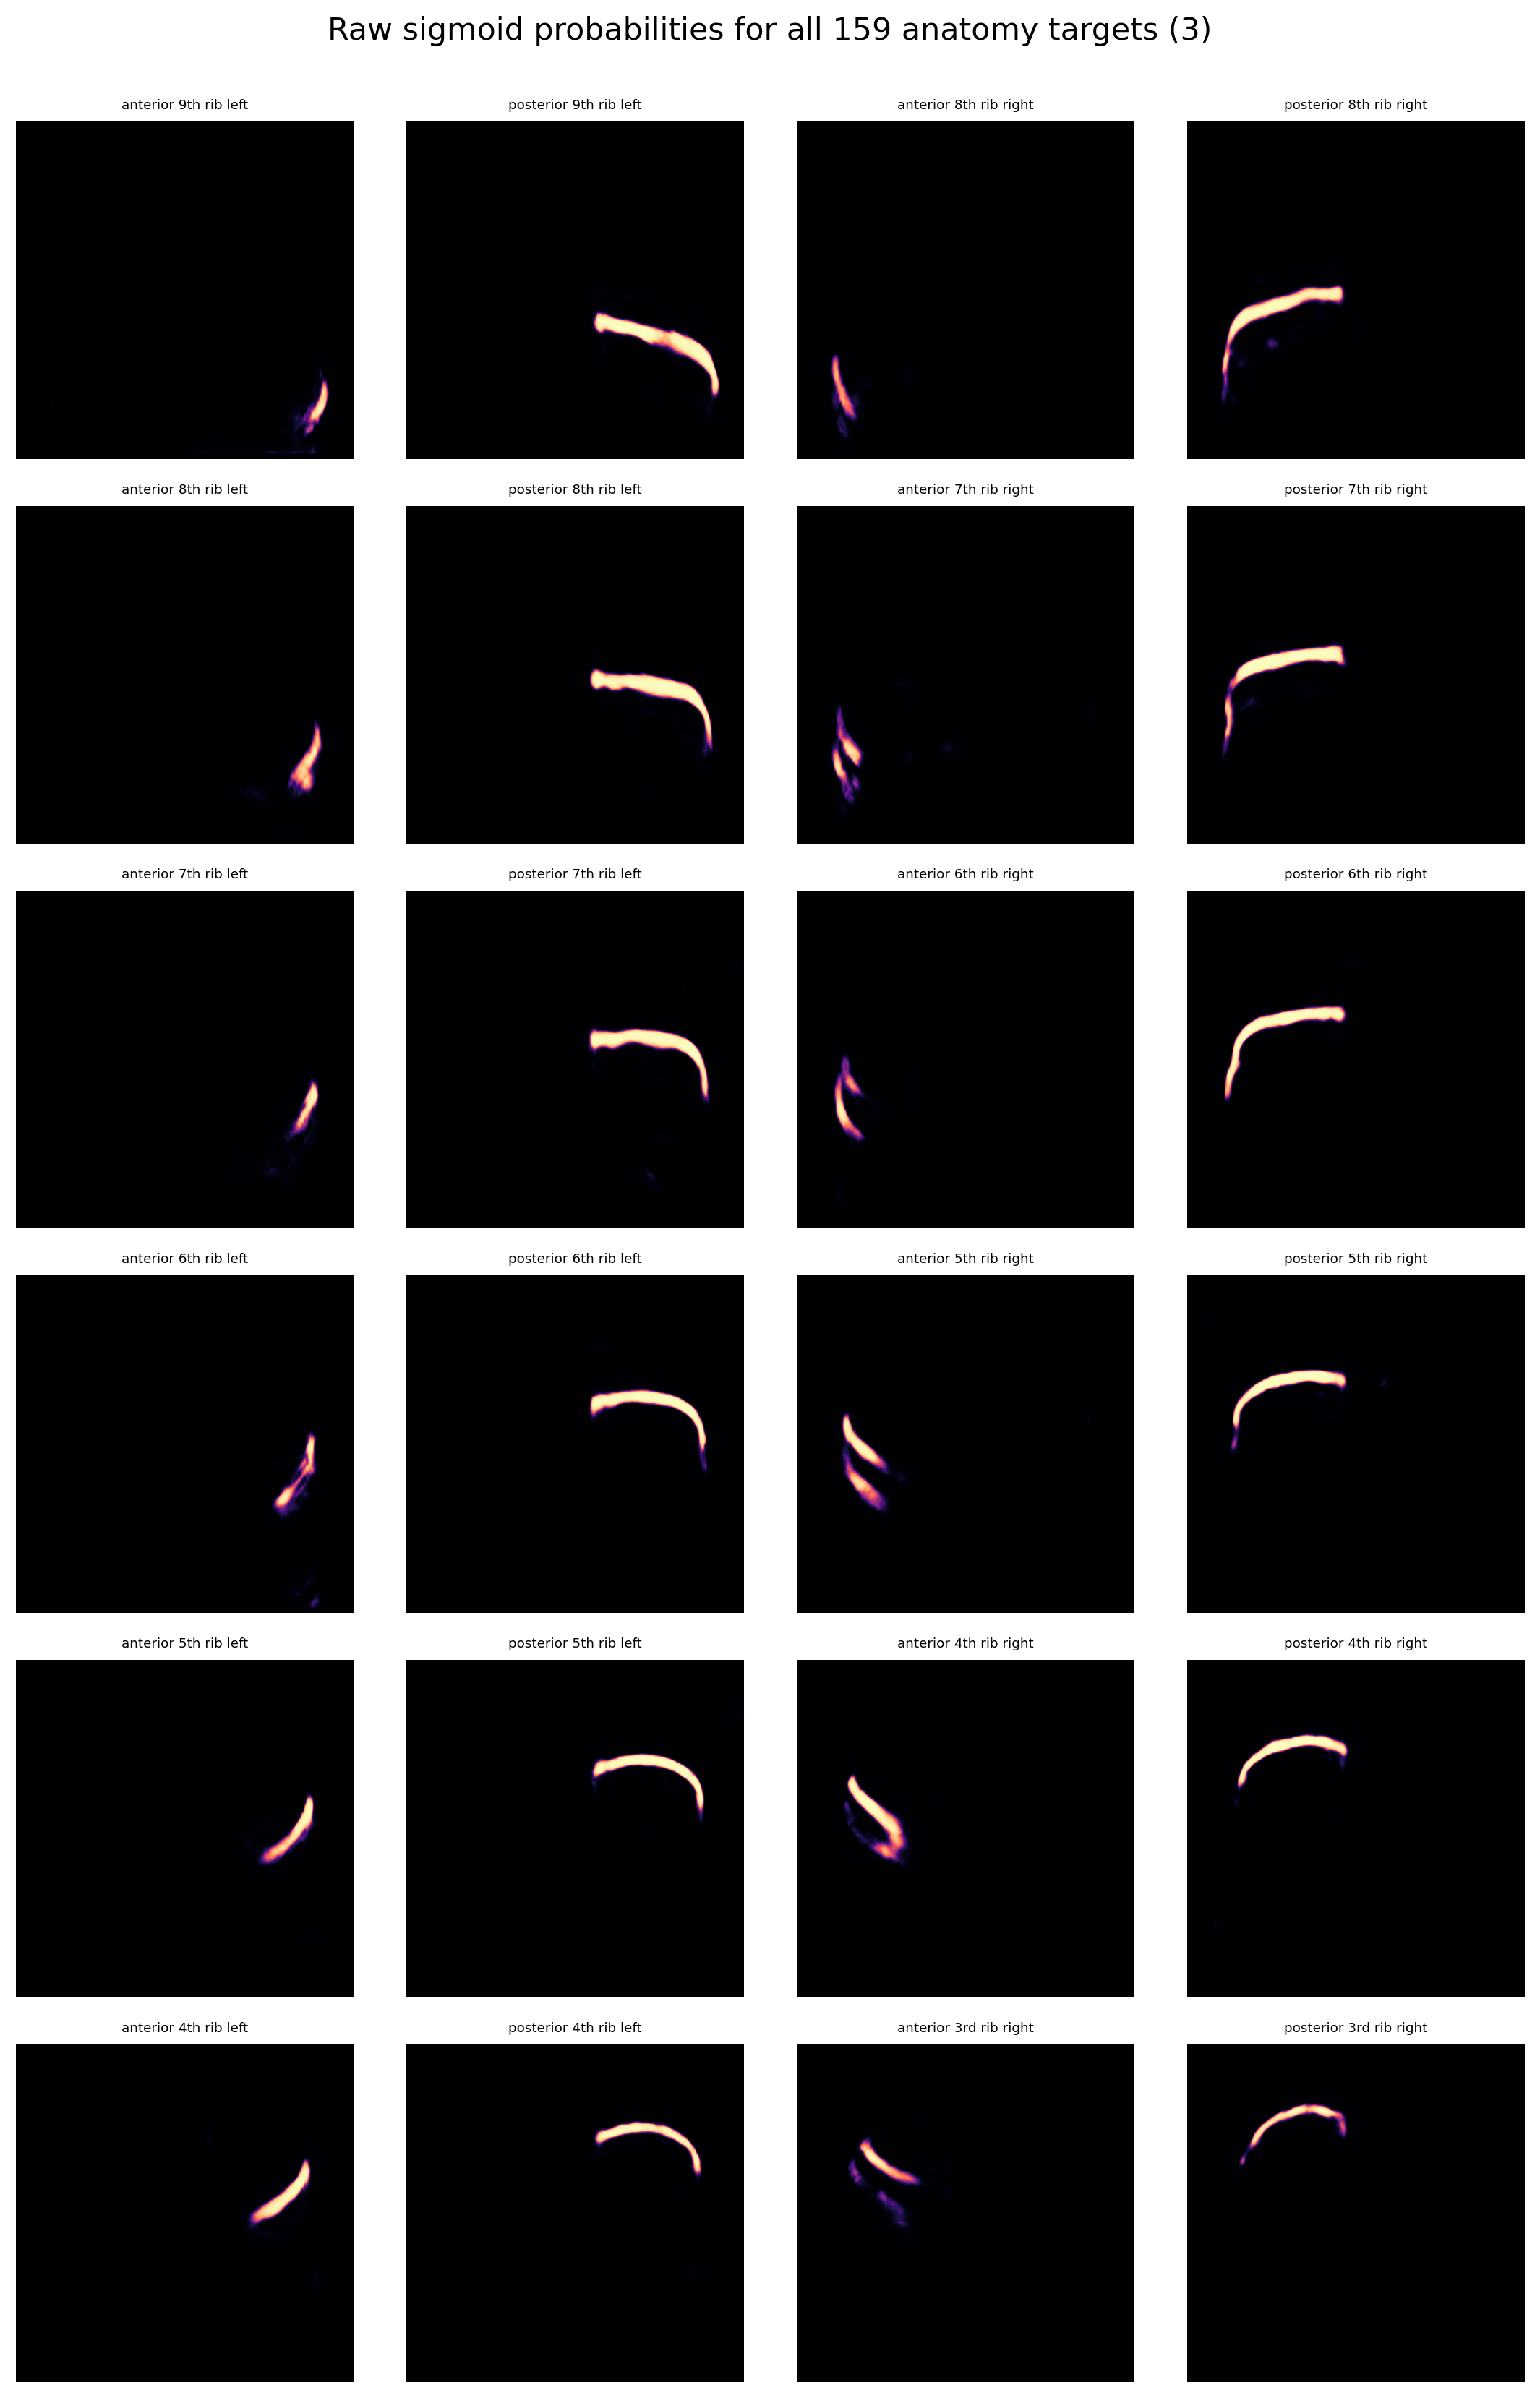

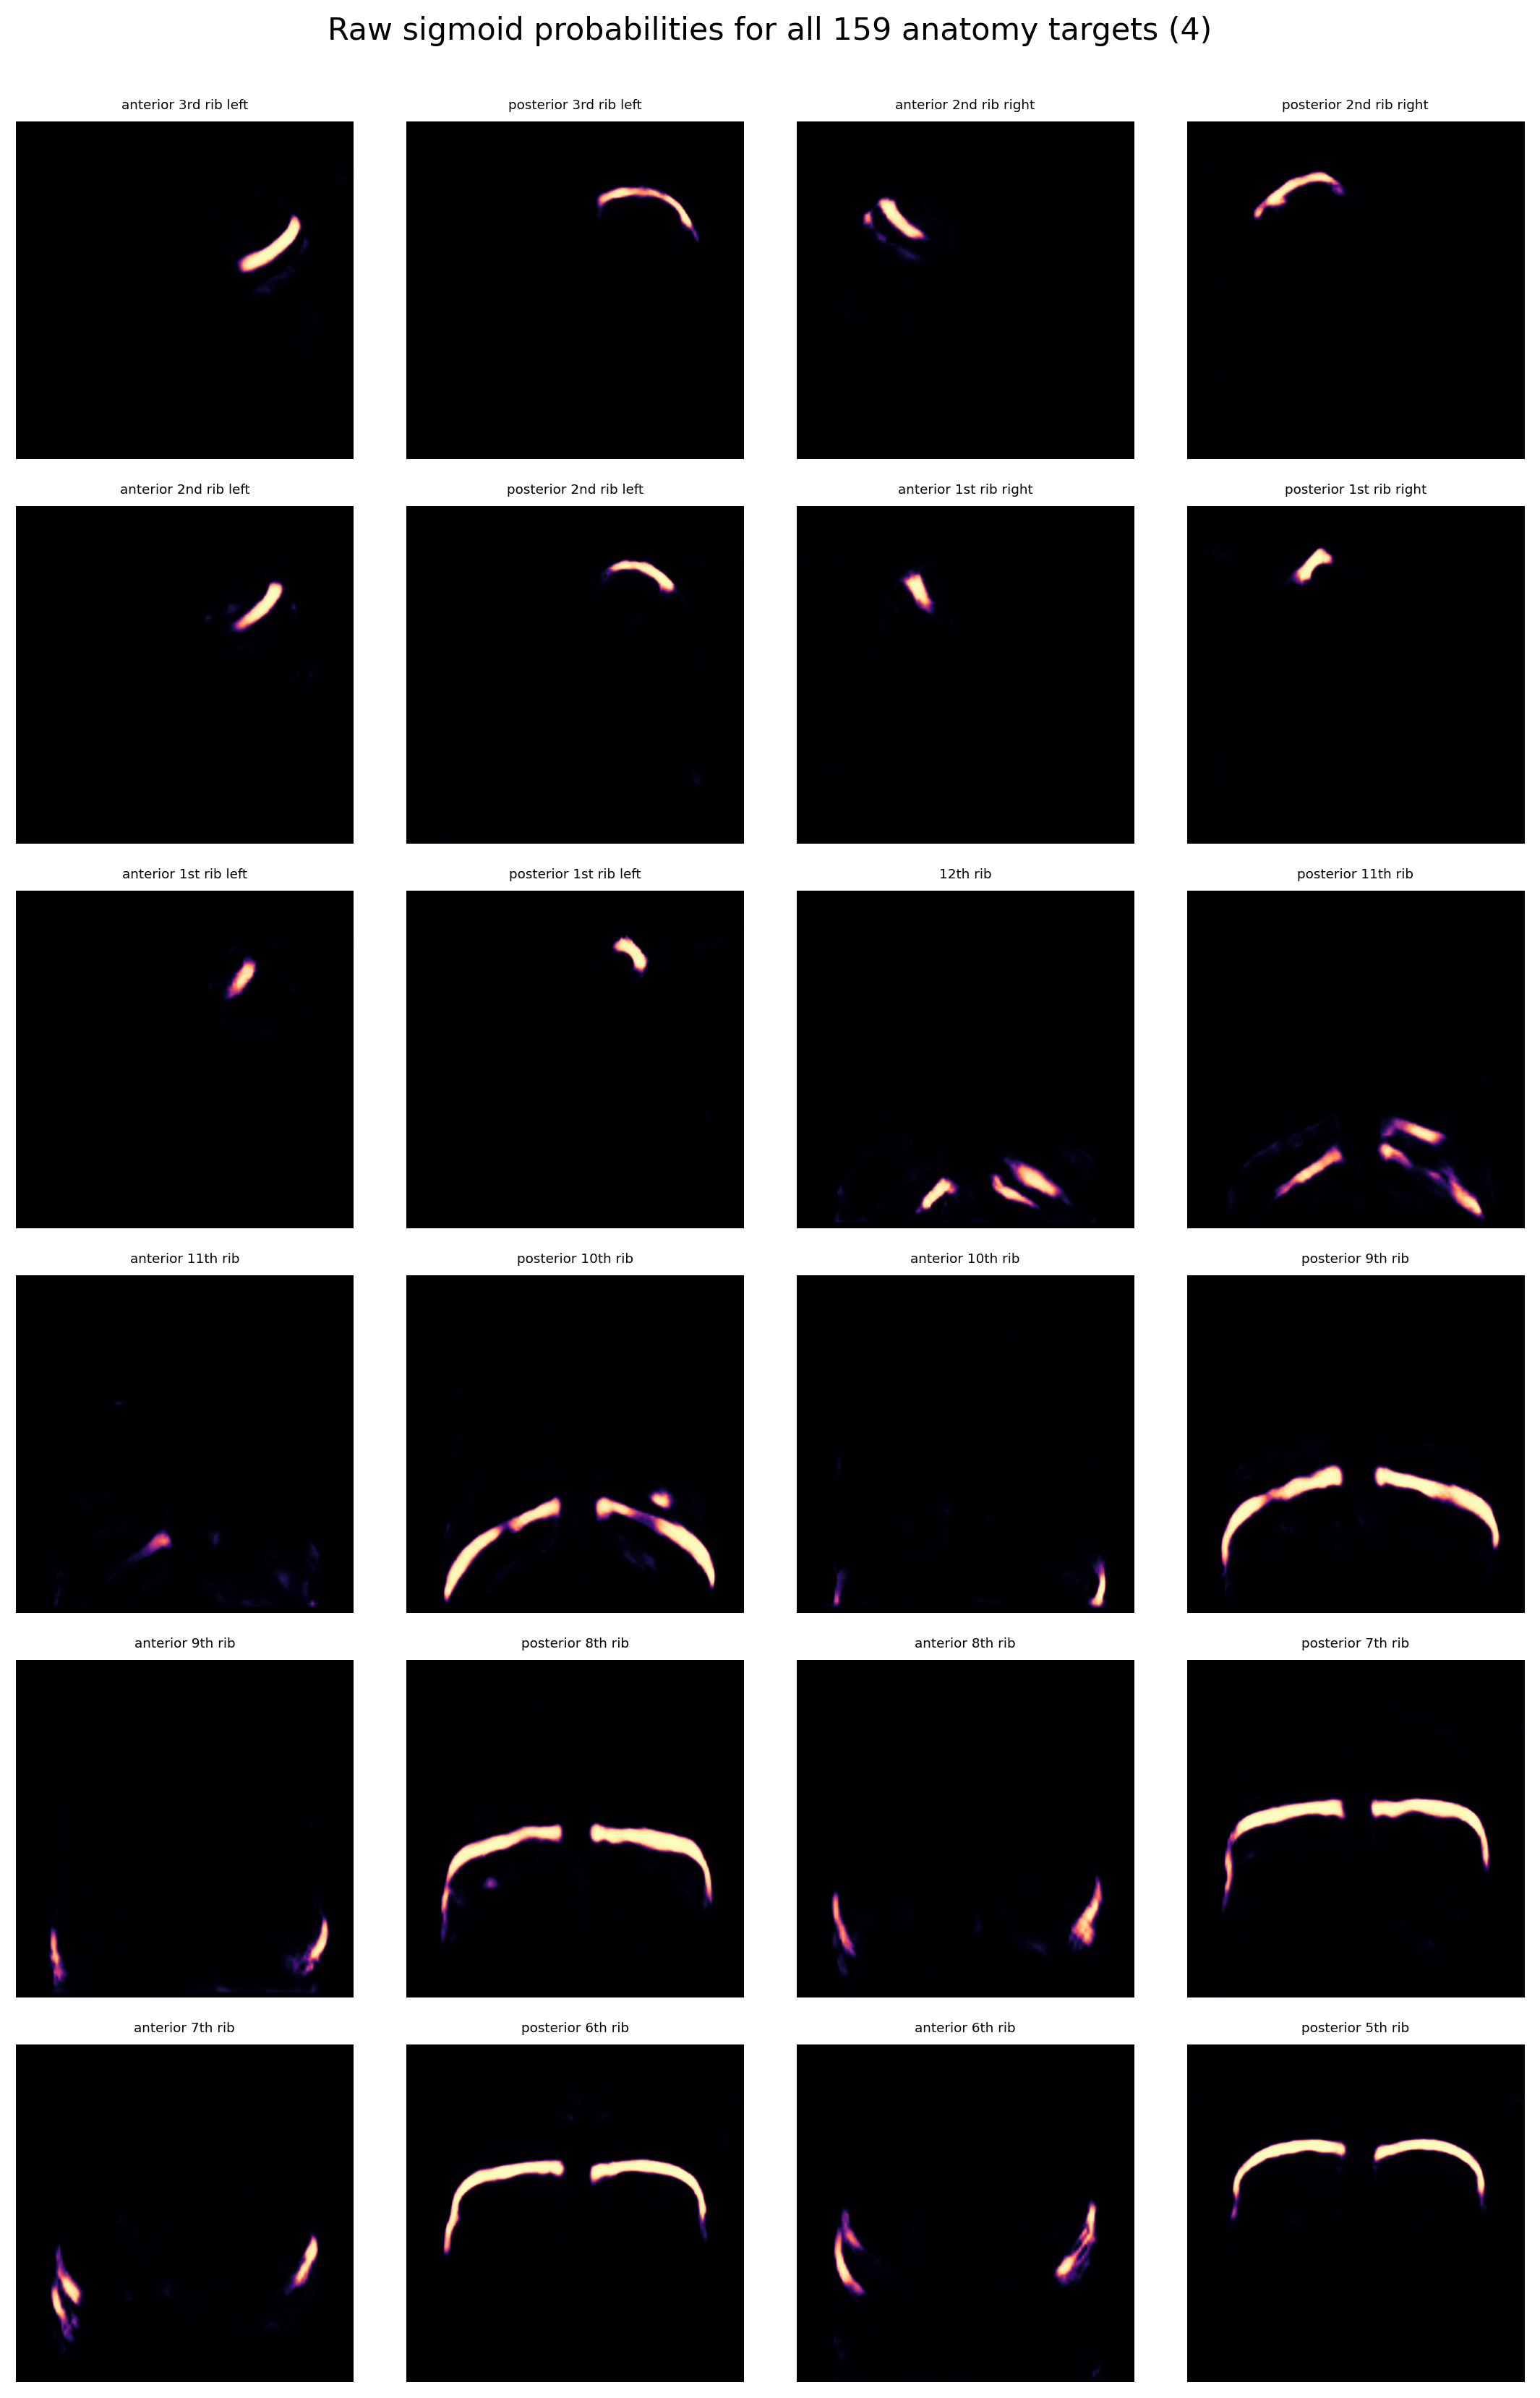

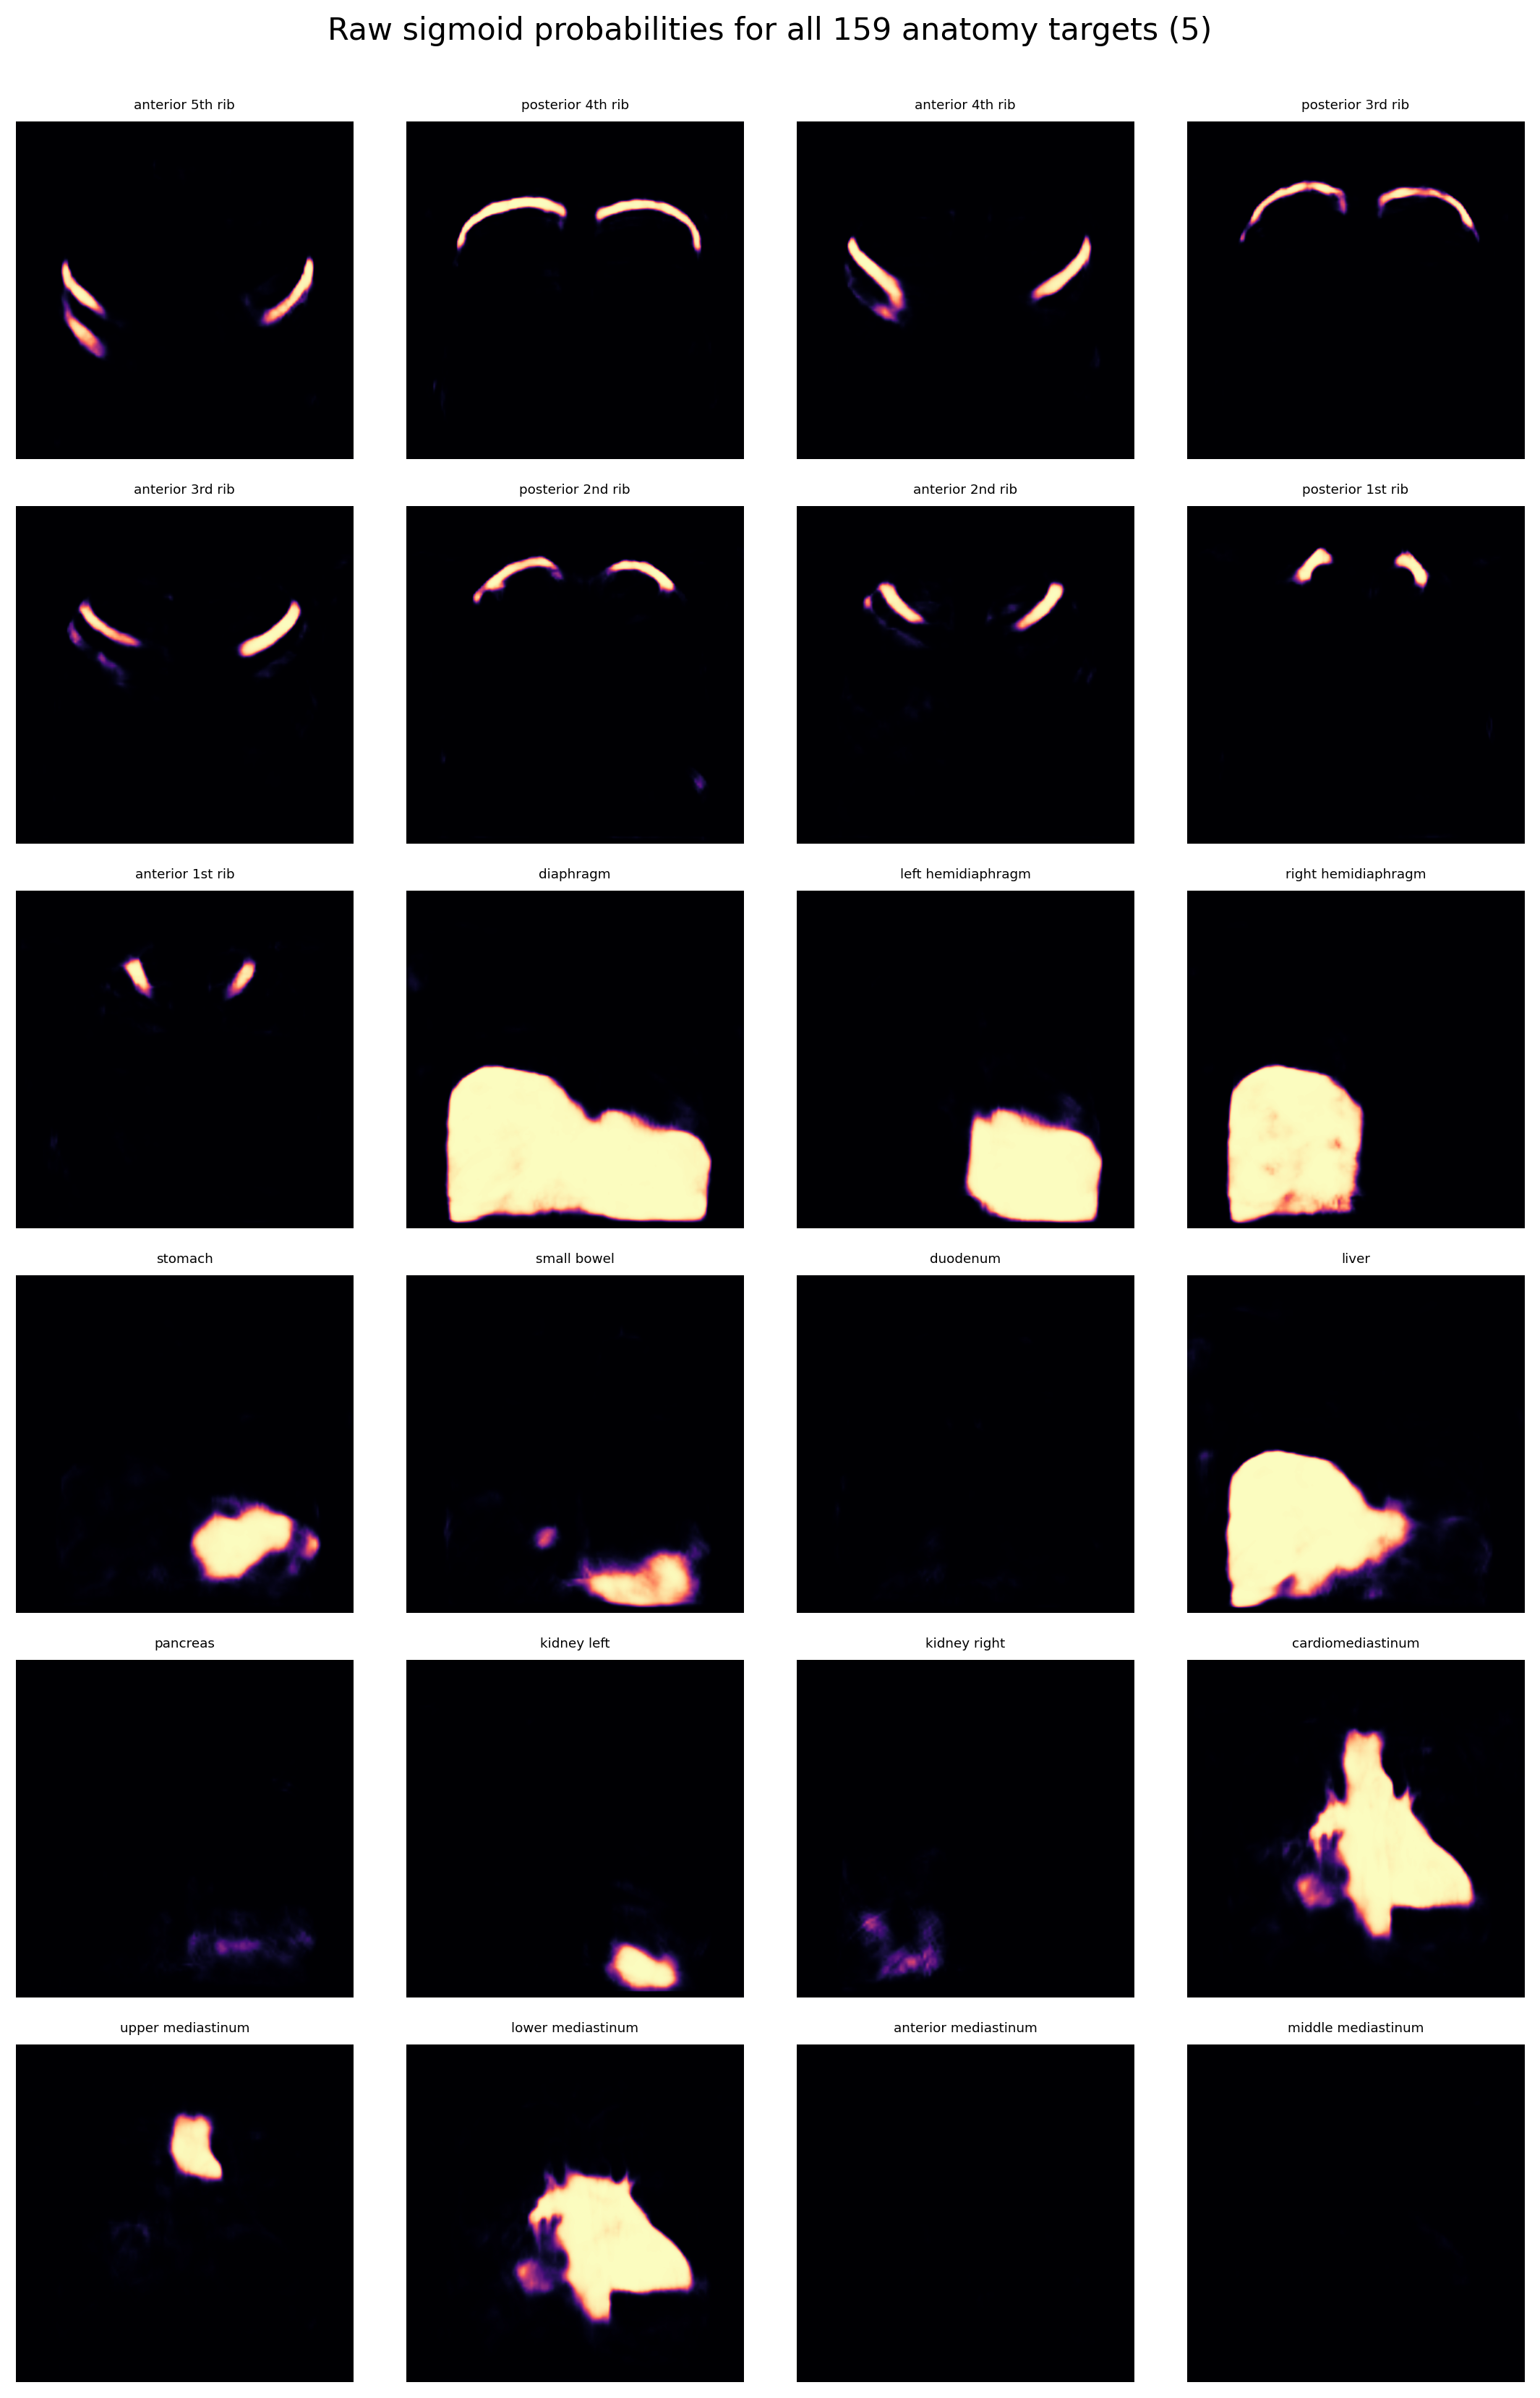

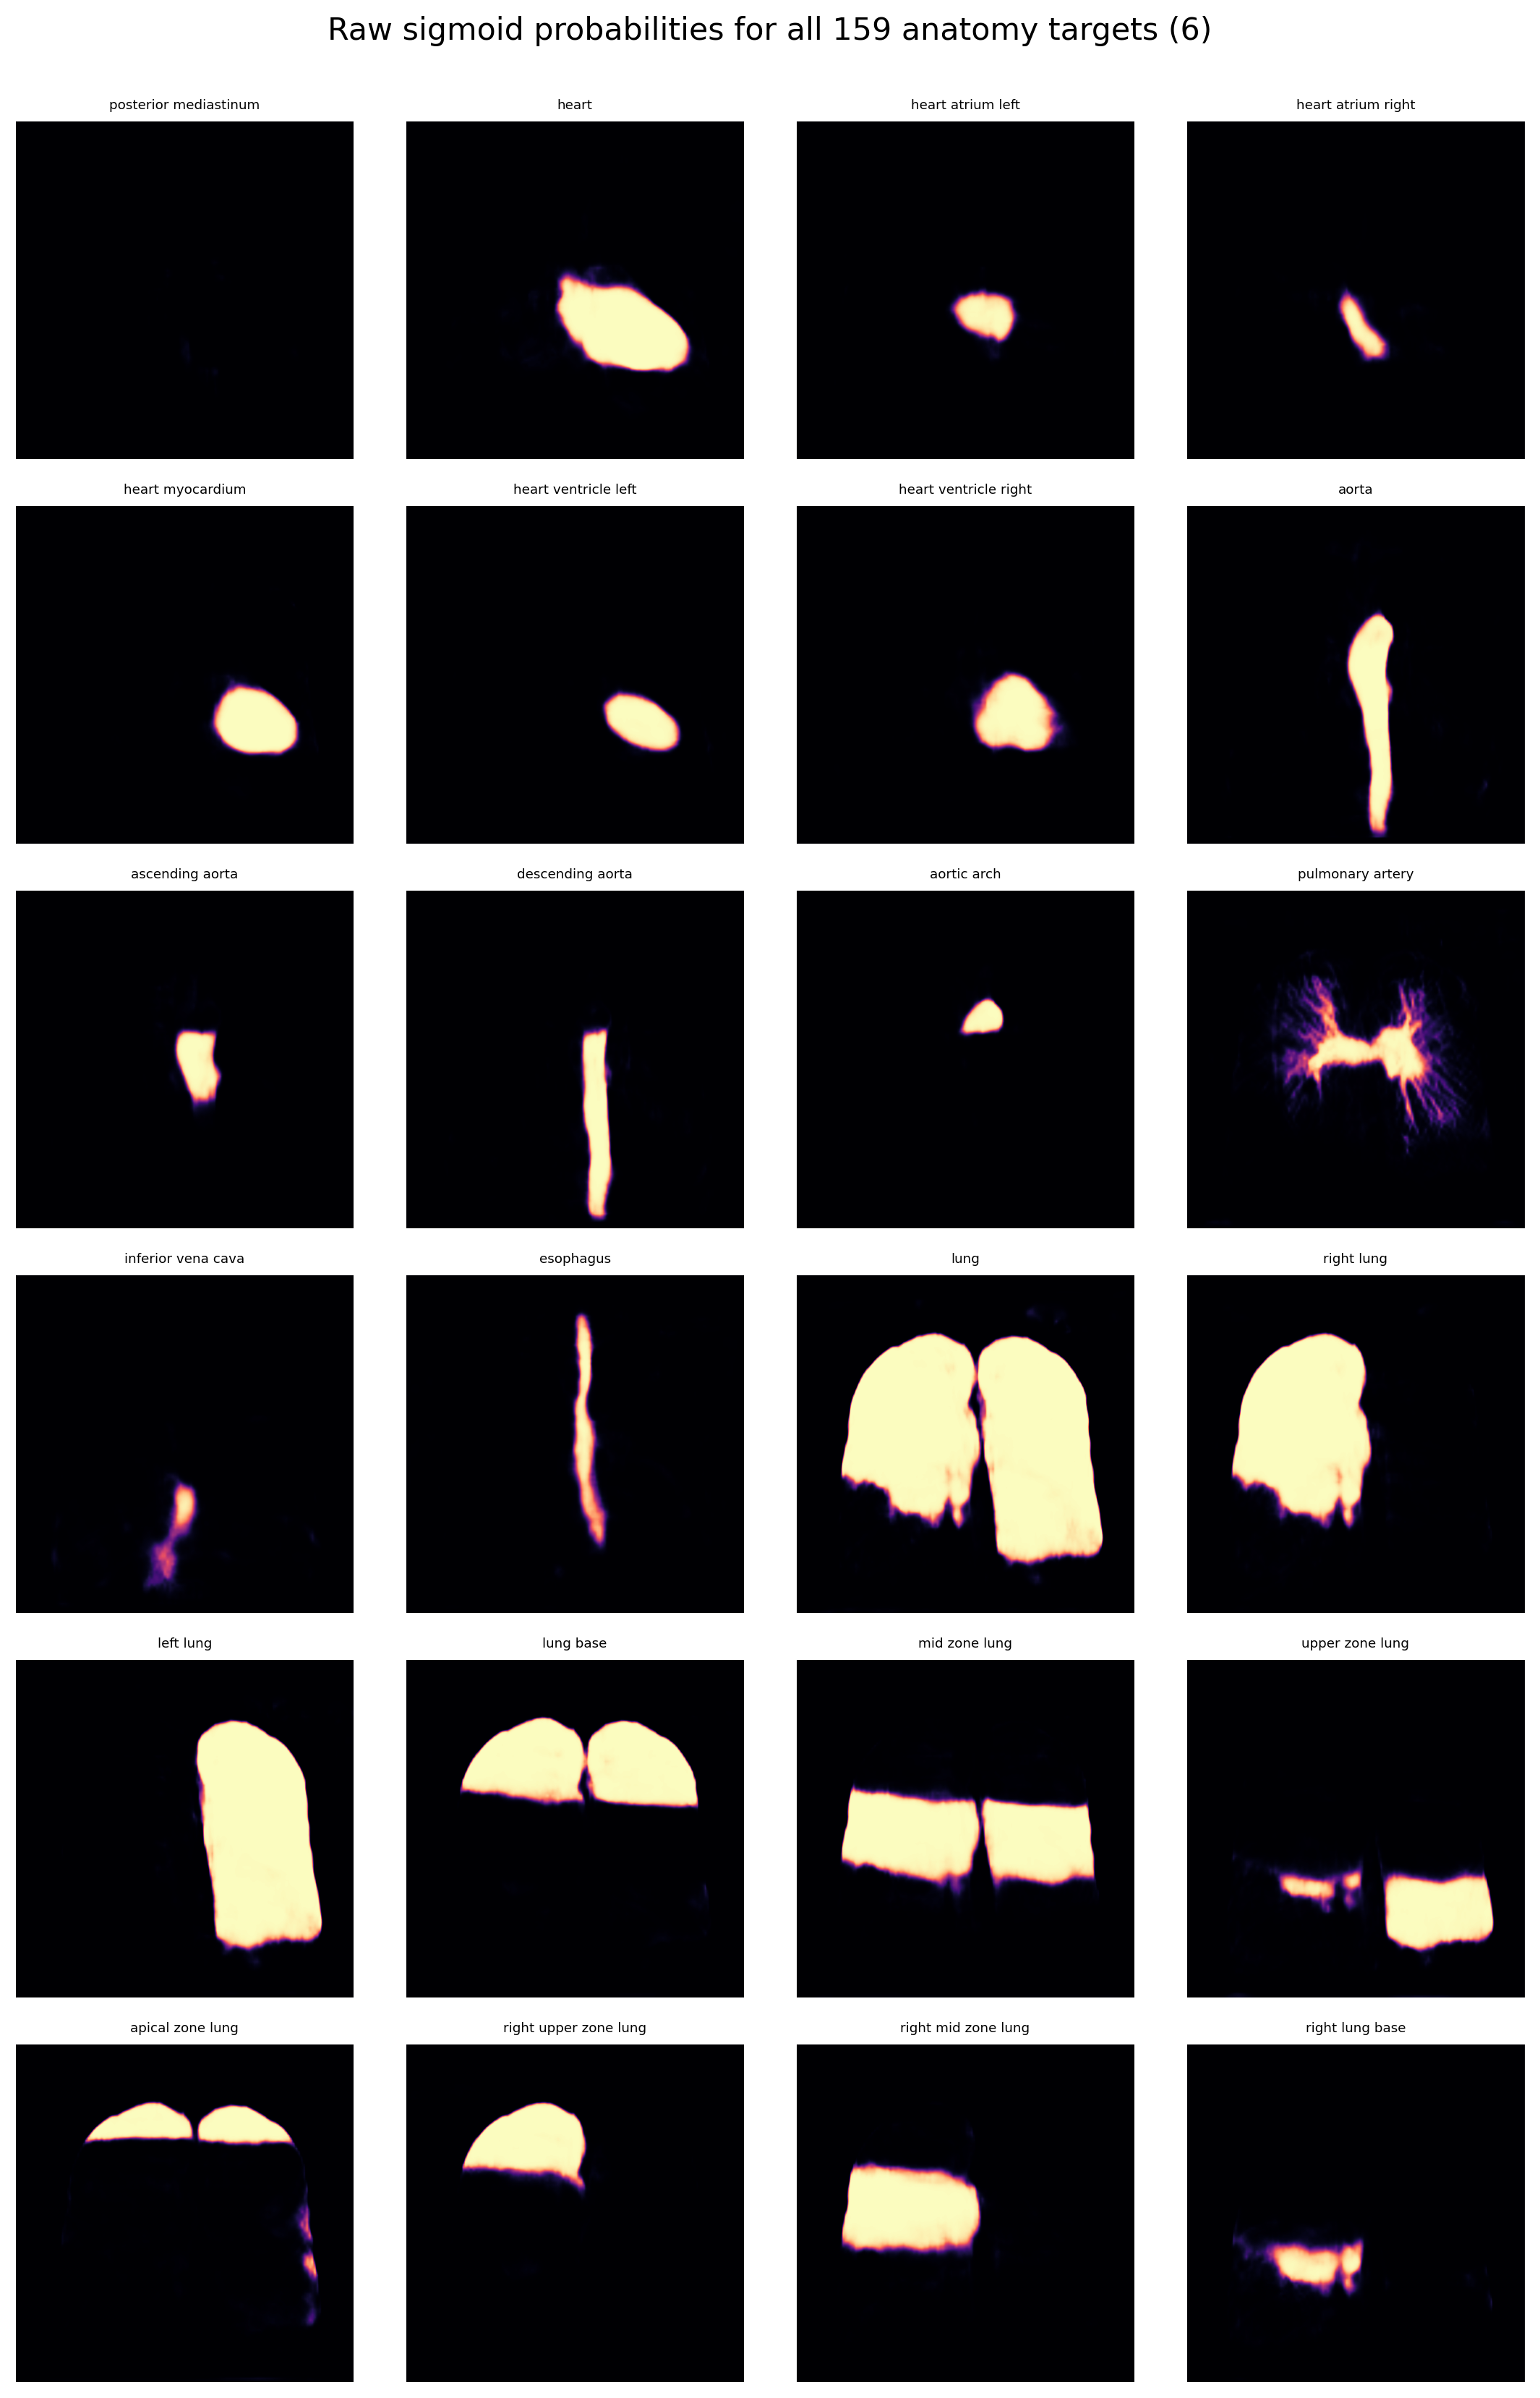

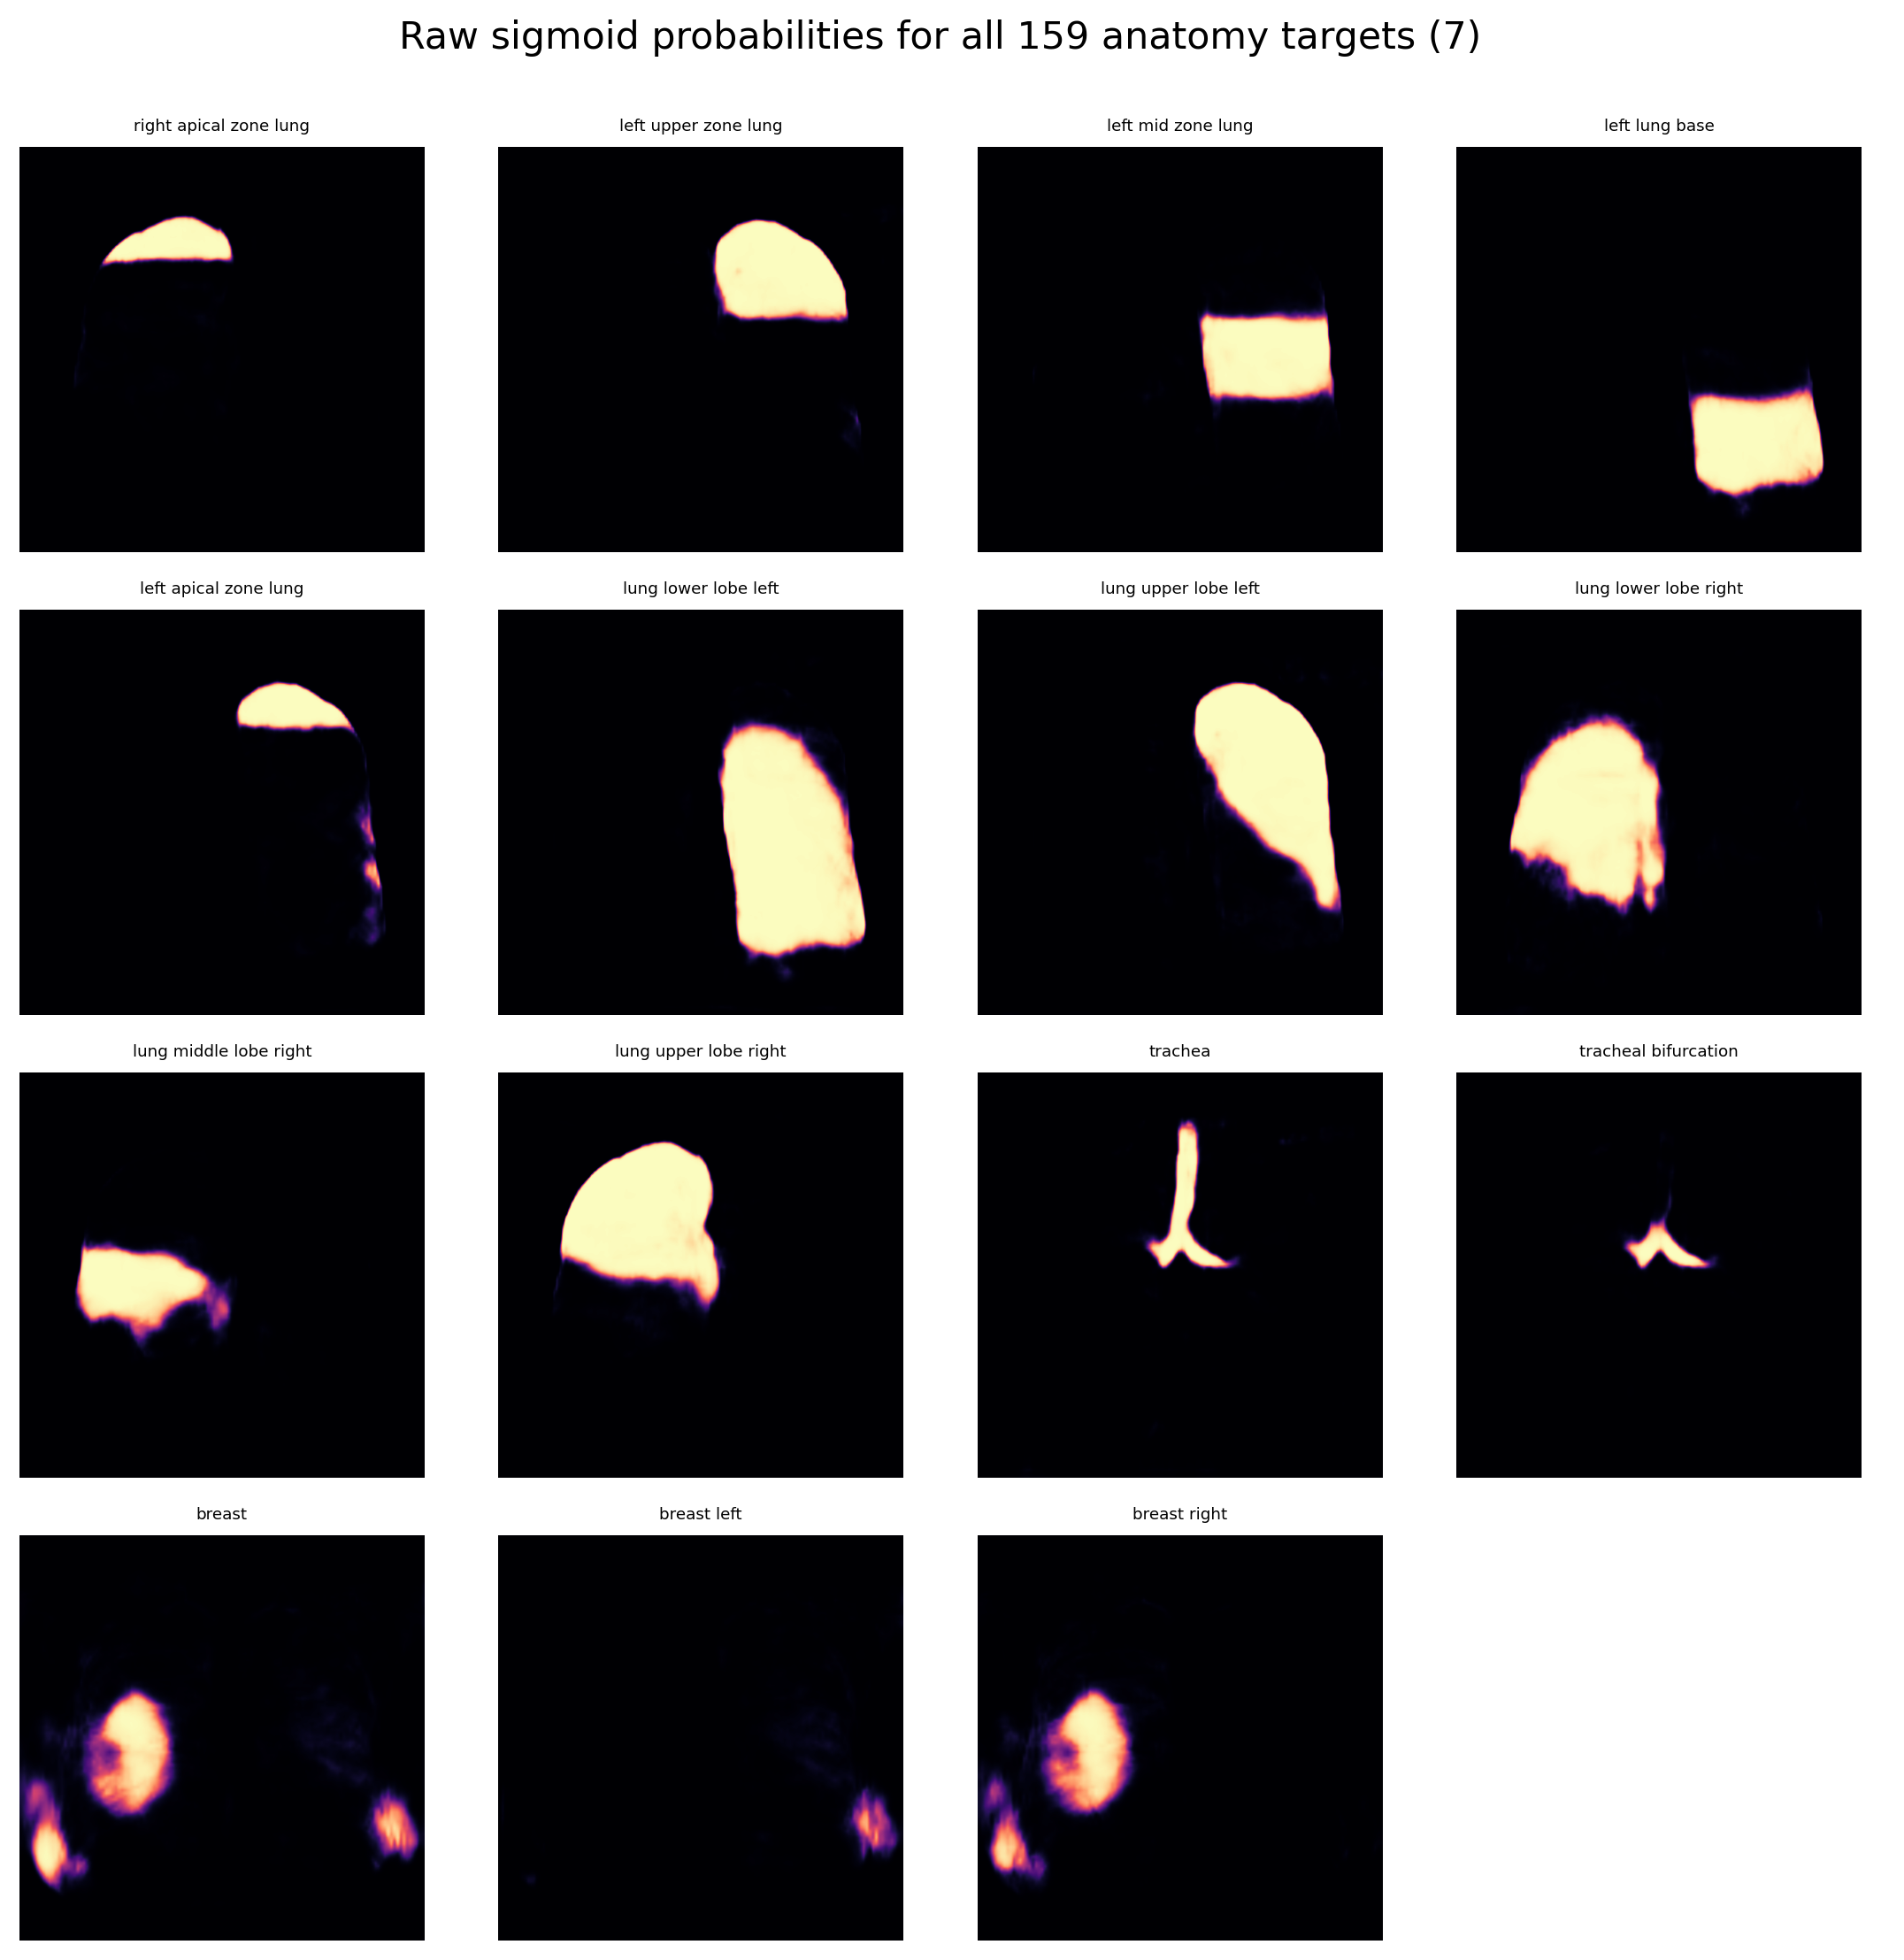

In [8]:
# Raw model output as probabilities, before thresholding.
show_all_targets(
    prob[0],
    title="Raw sigmoid probabilities for all 159 anatomy targets",
    cmap="magma",
    vmin=0,
    vmax=1,
)


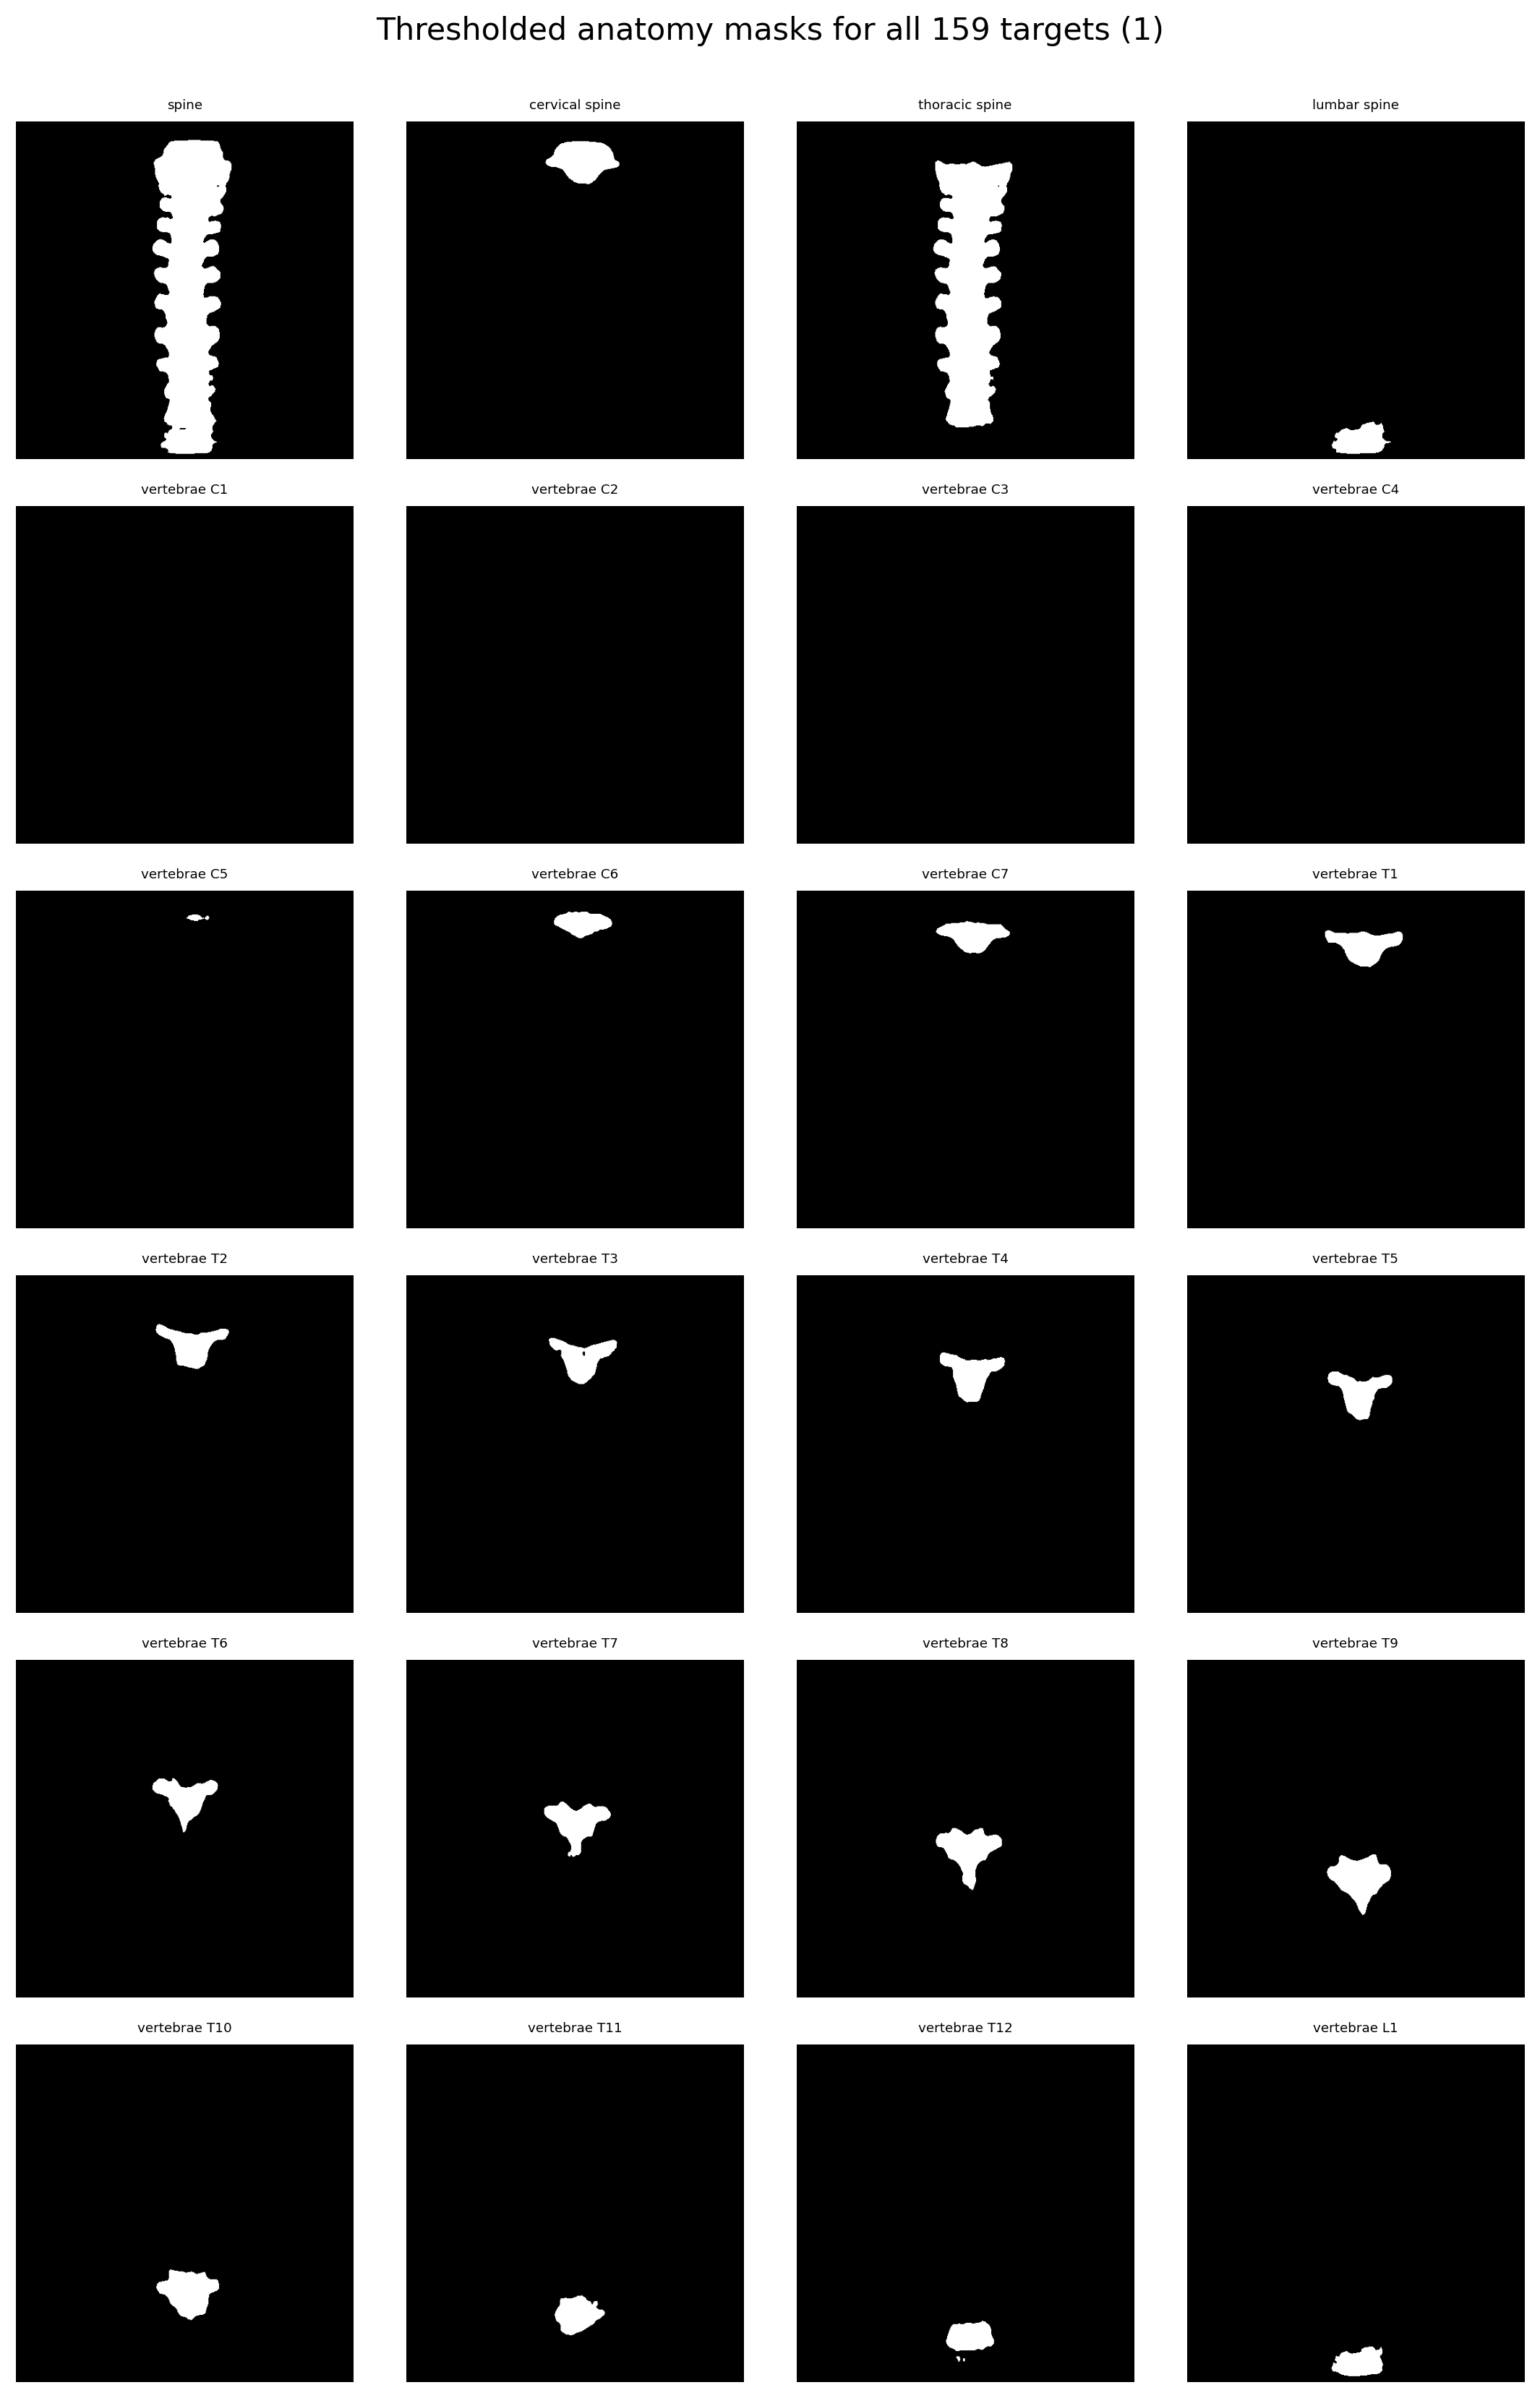

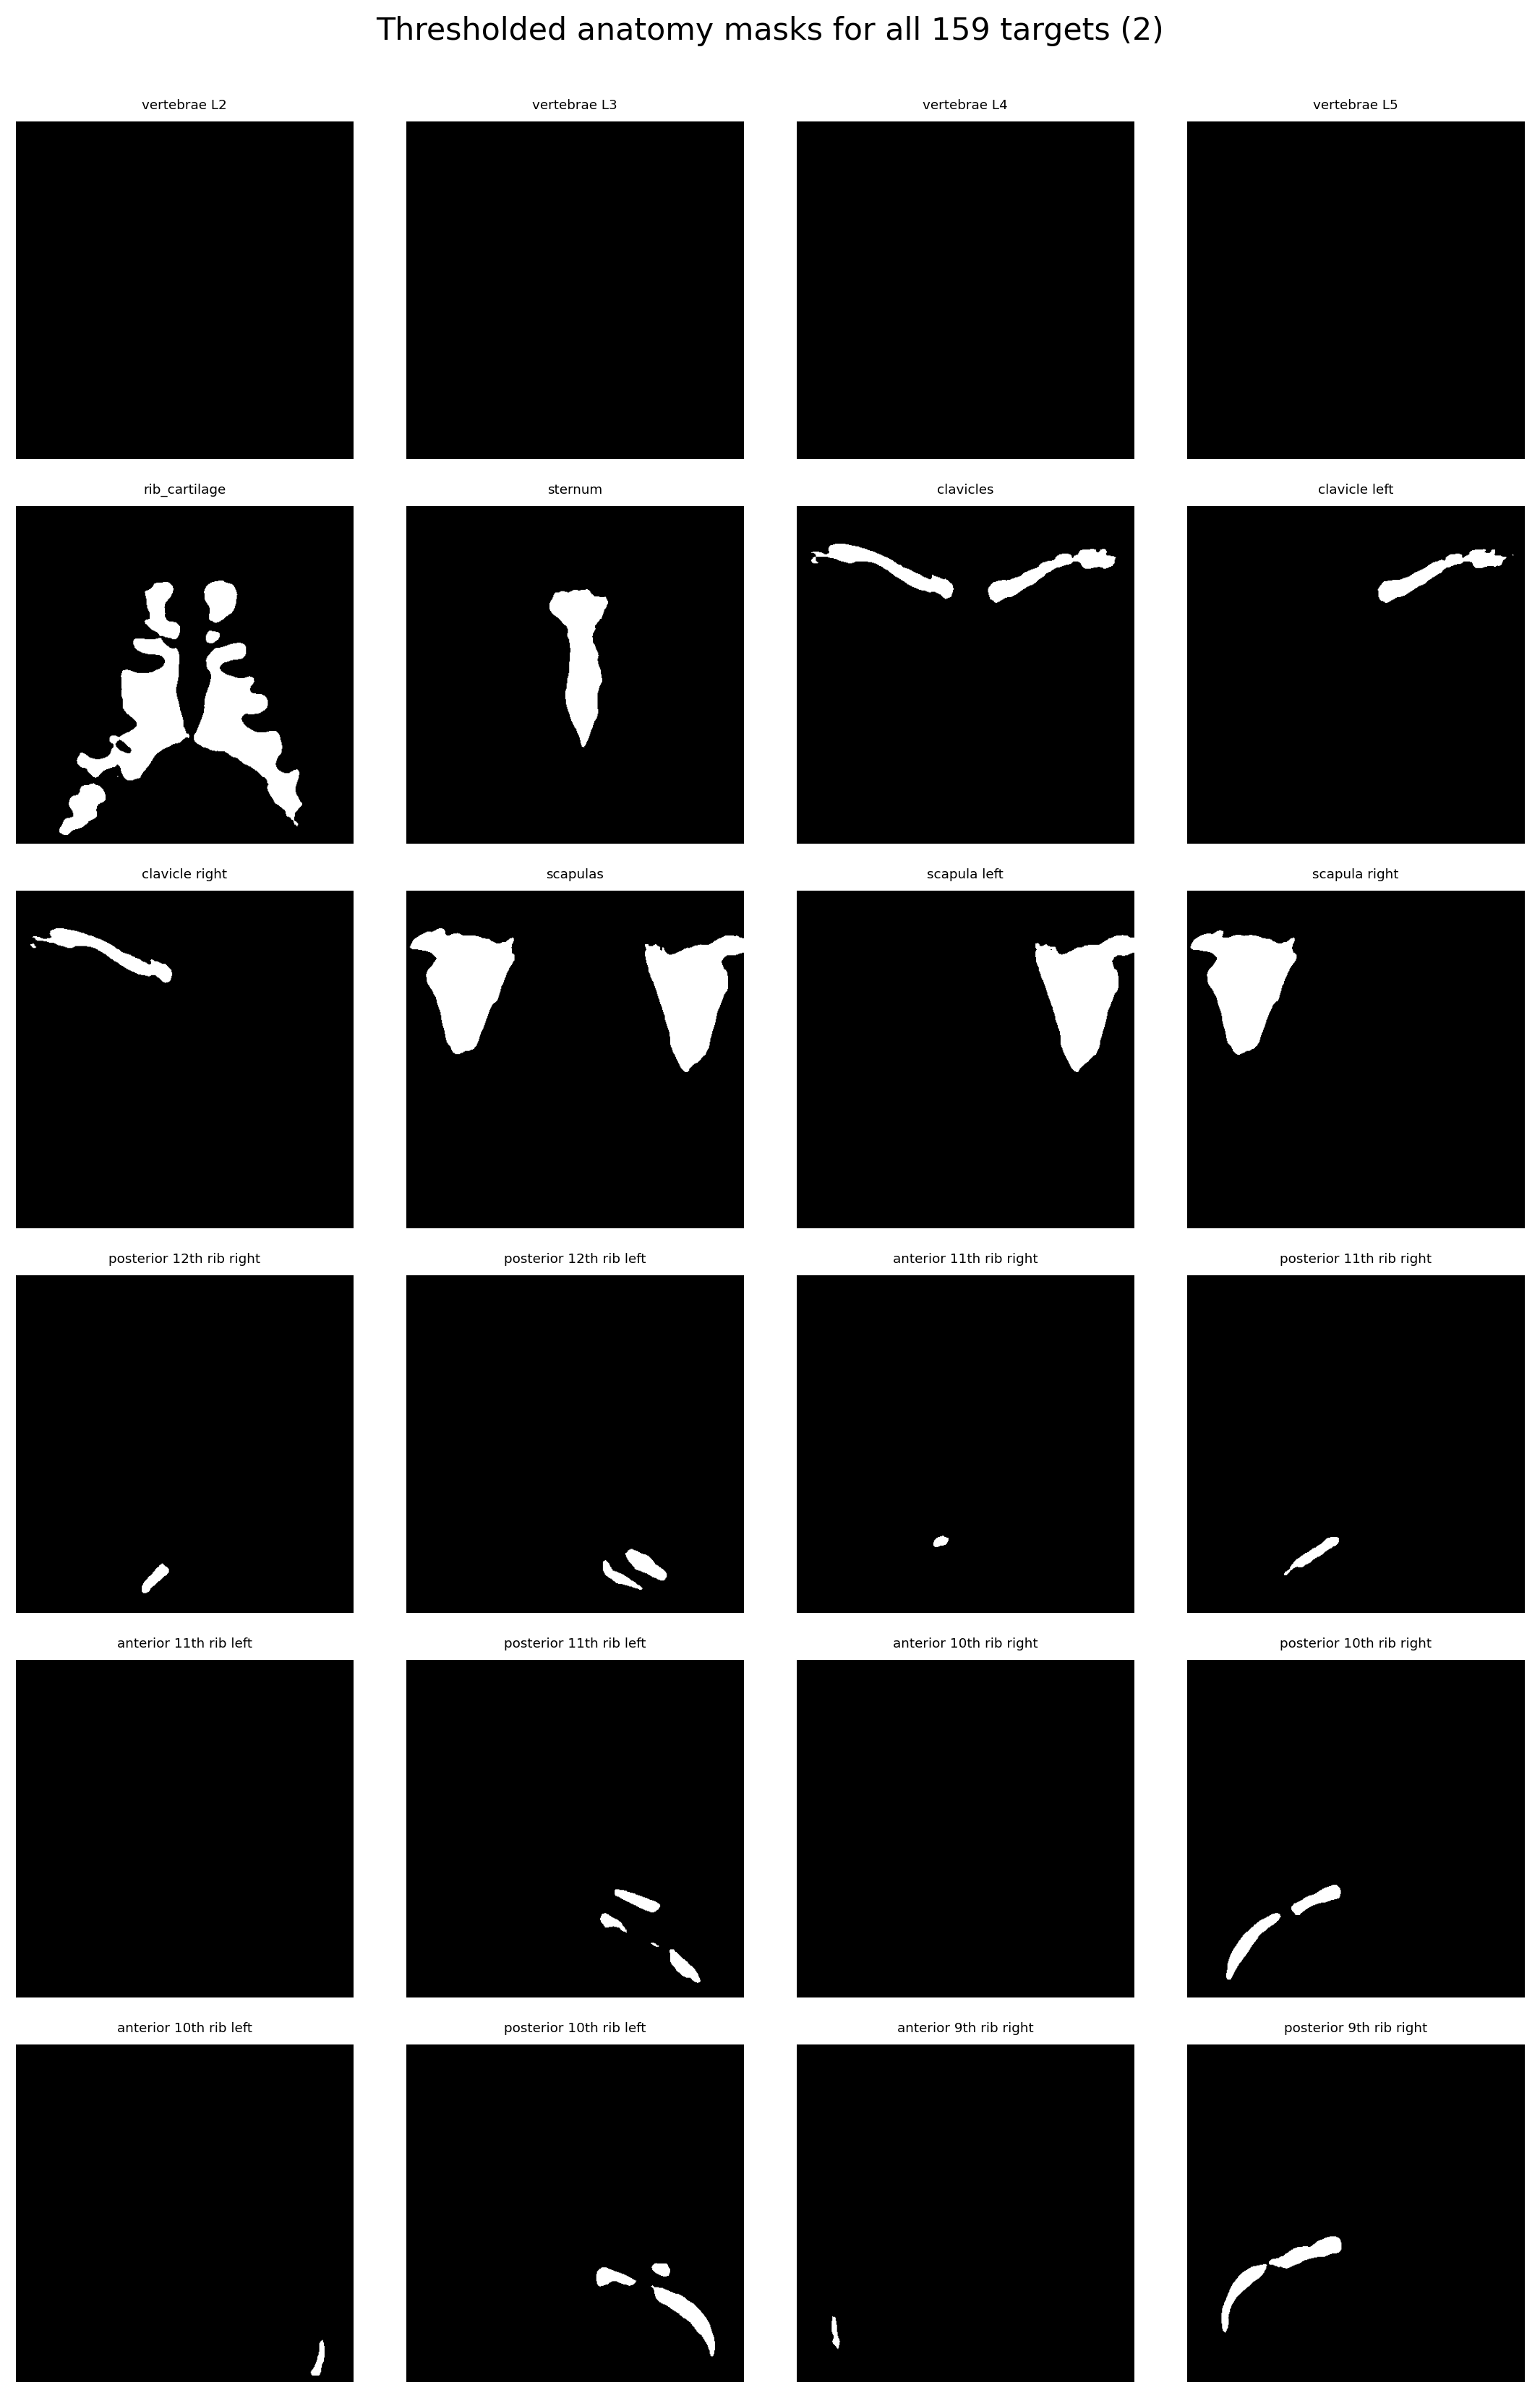

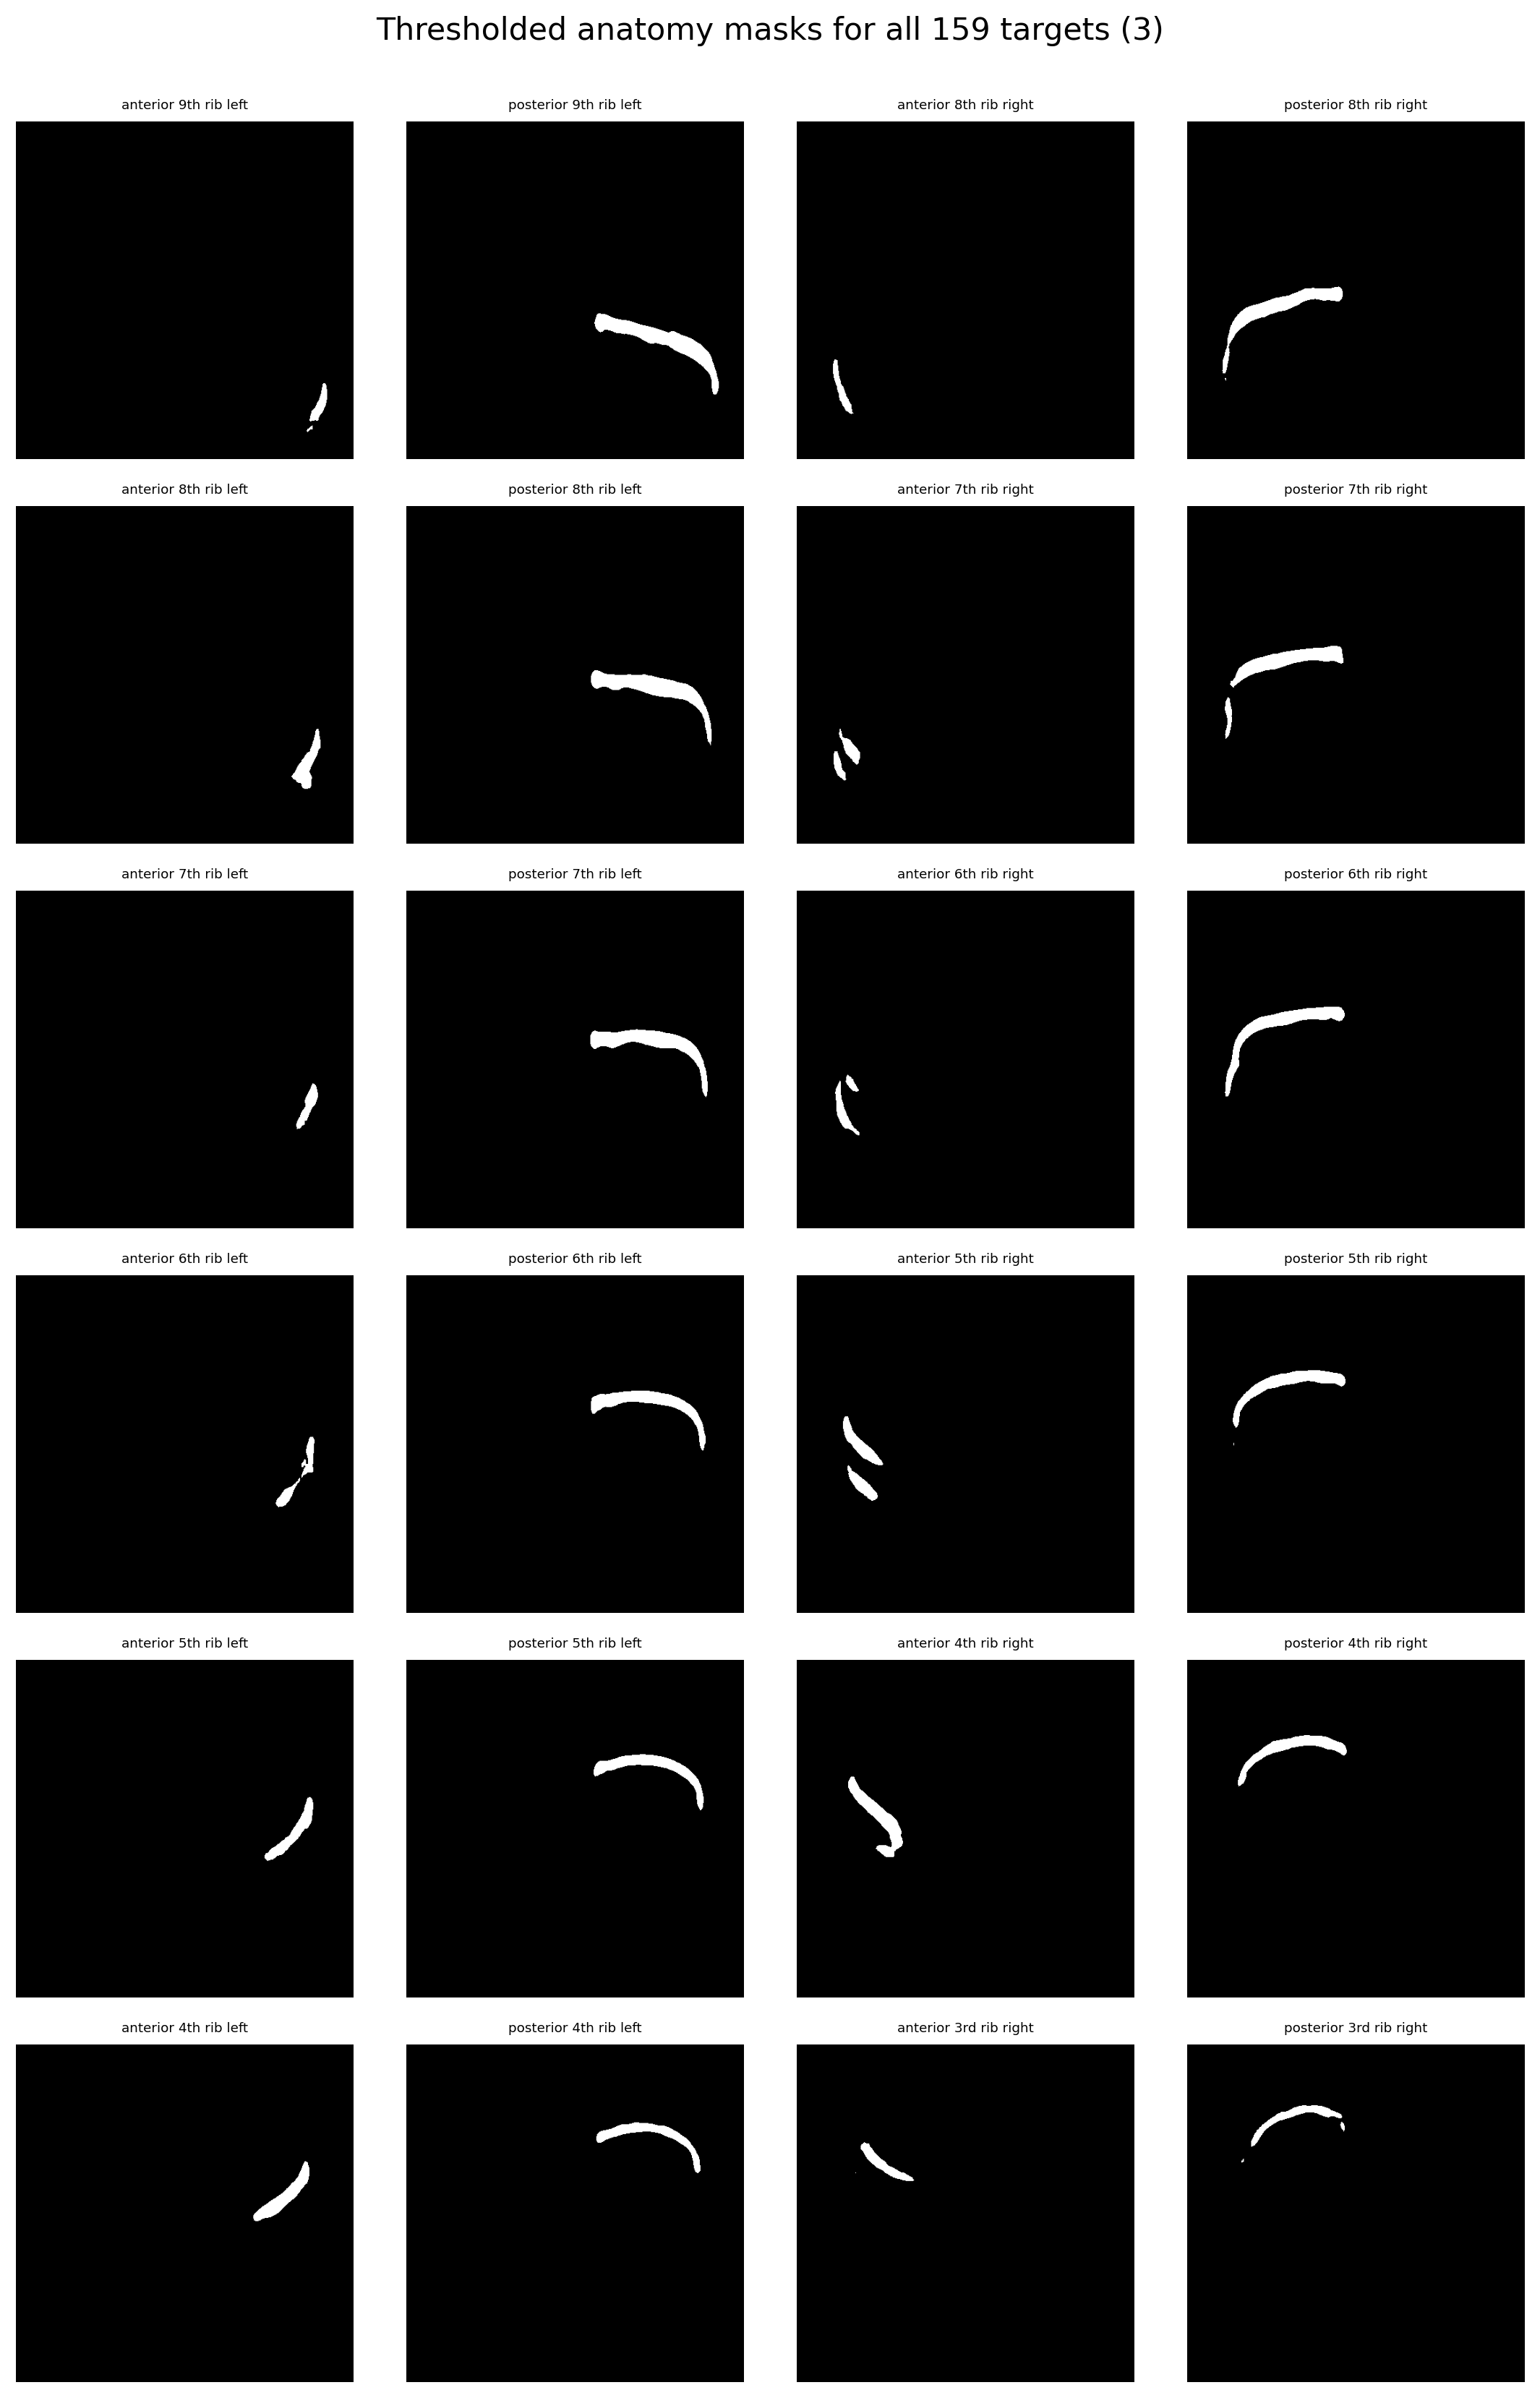

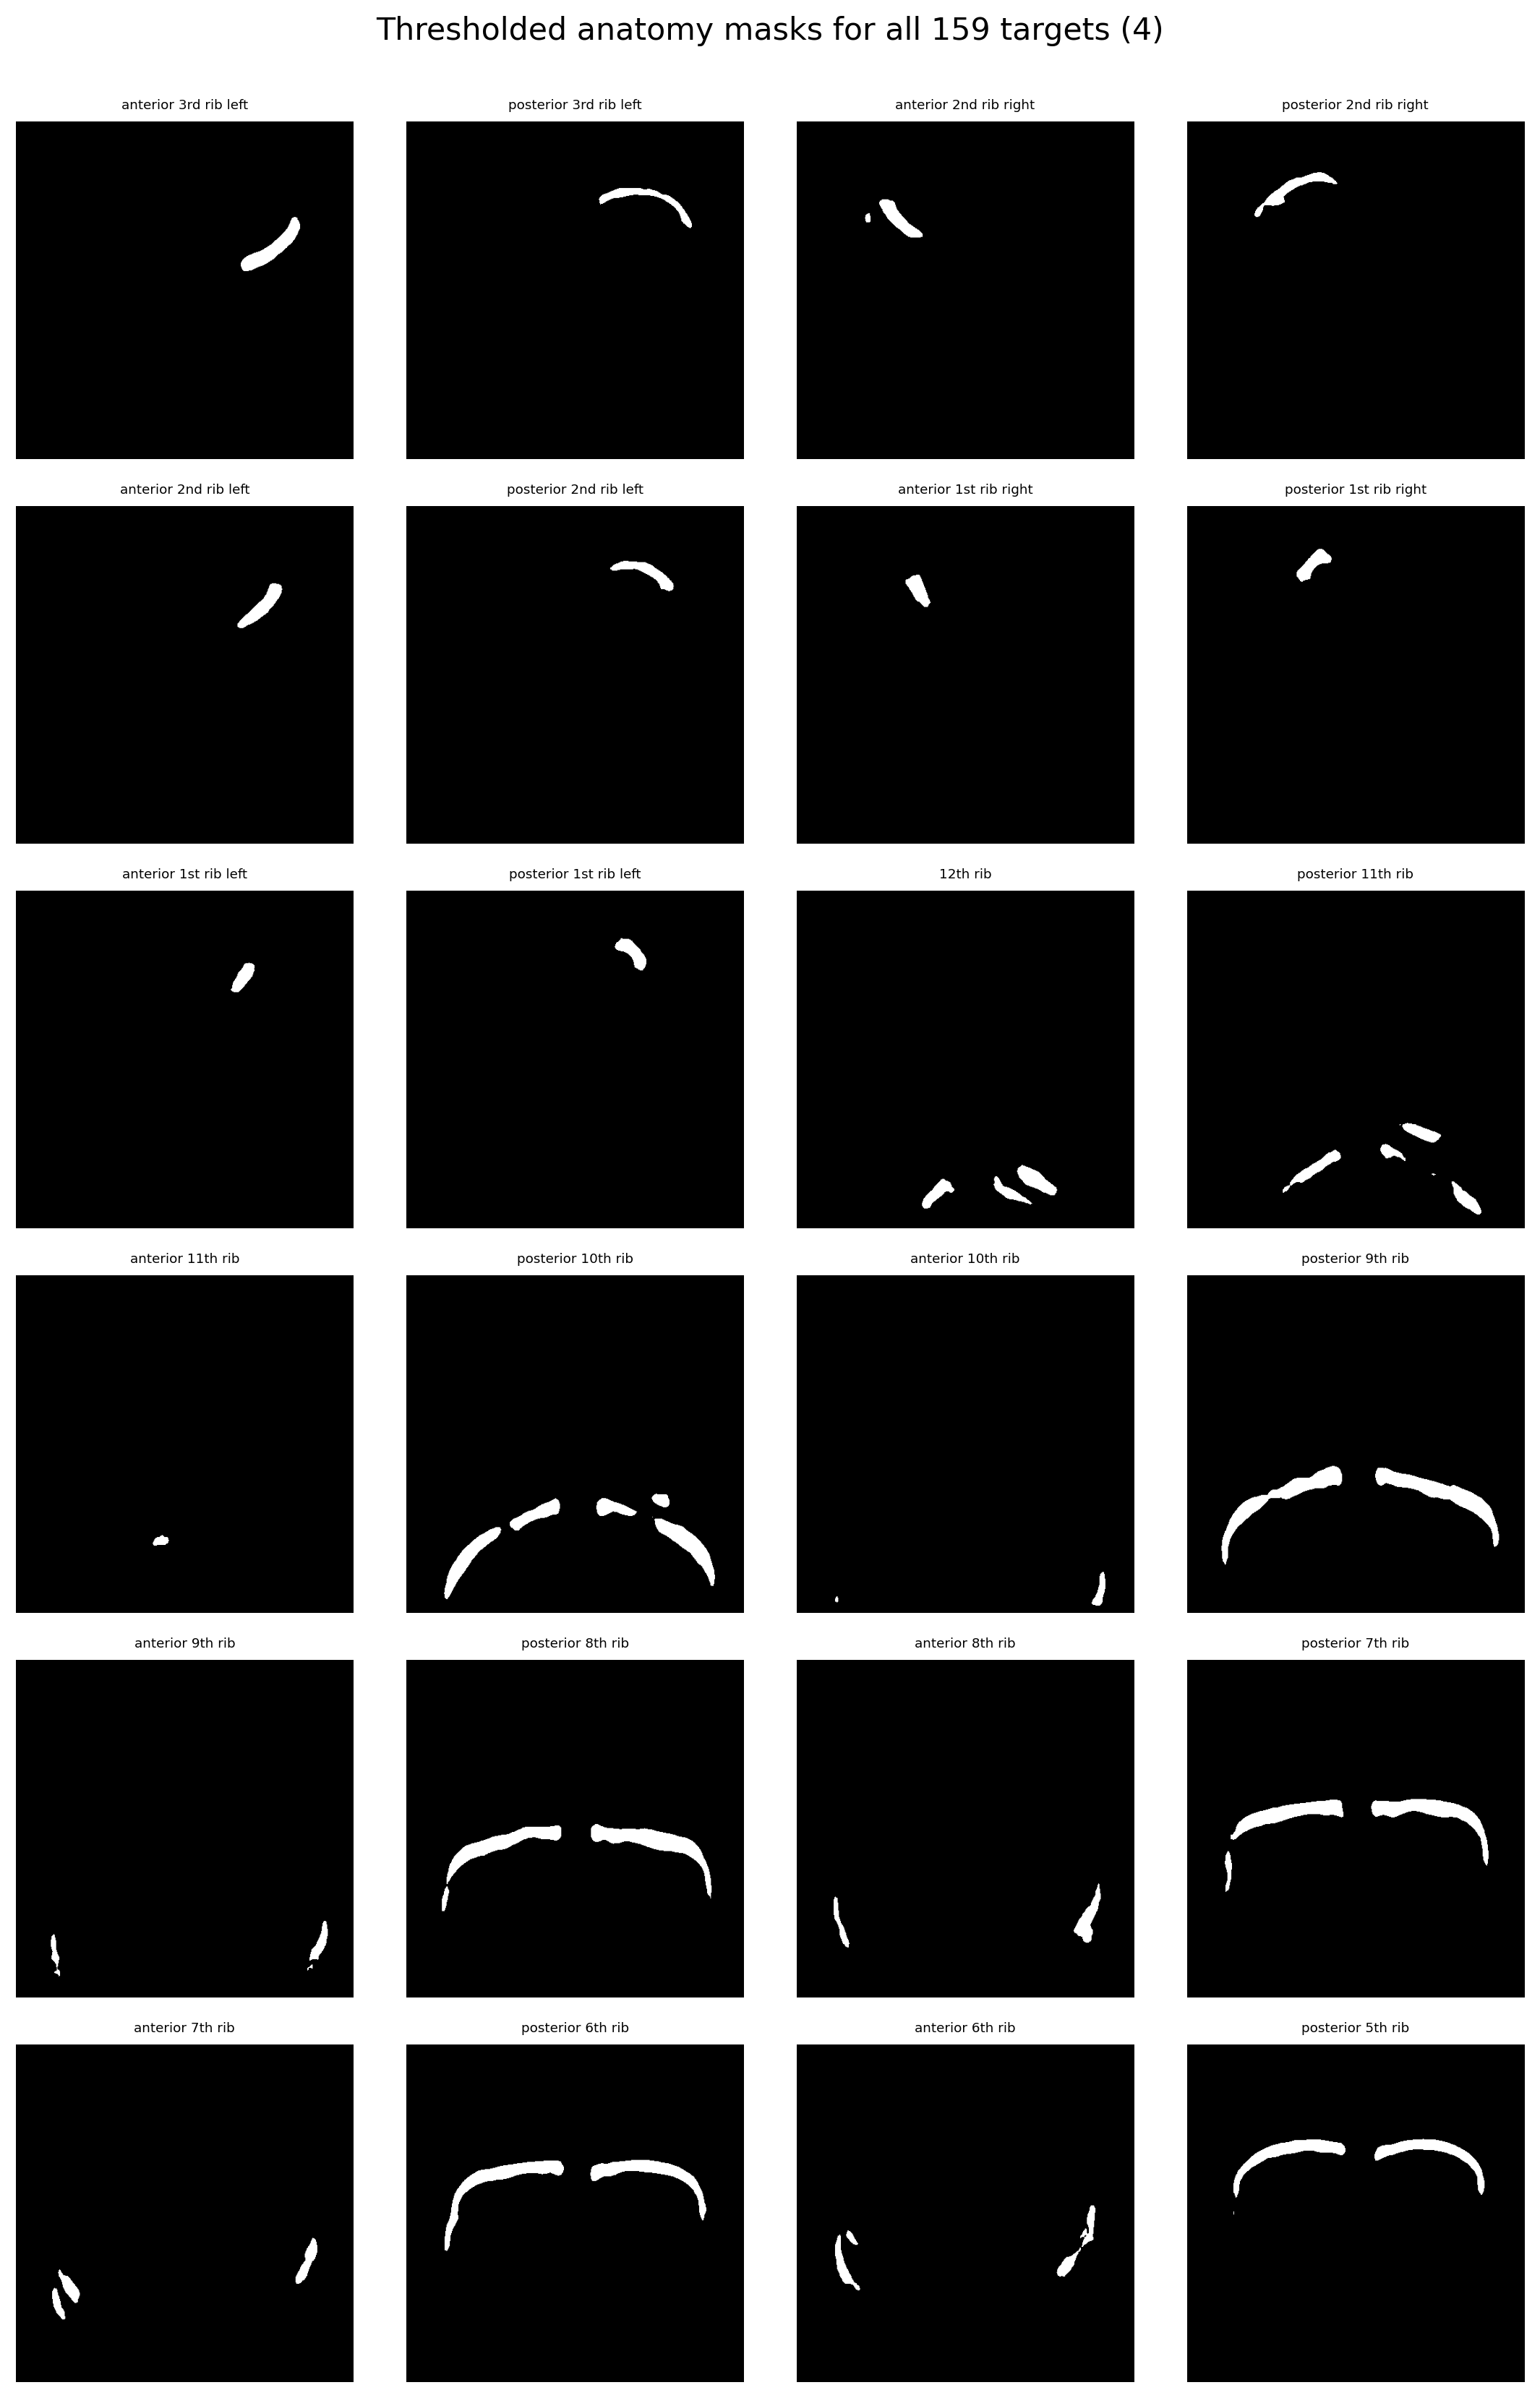

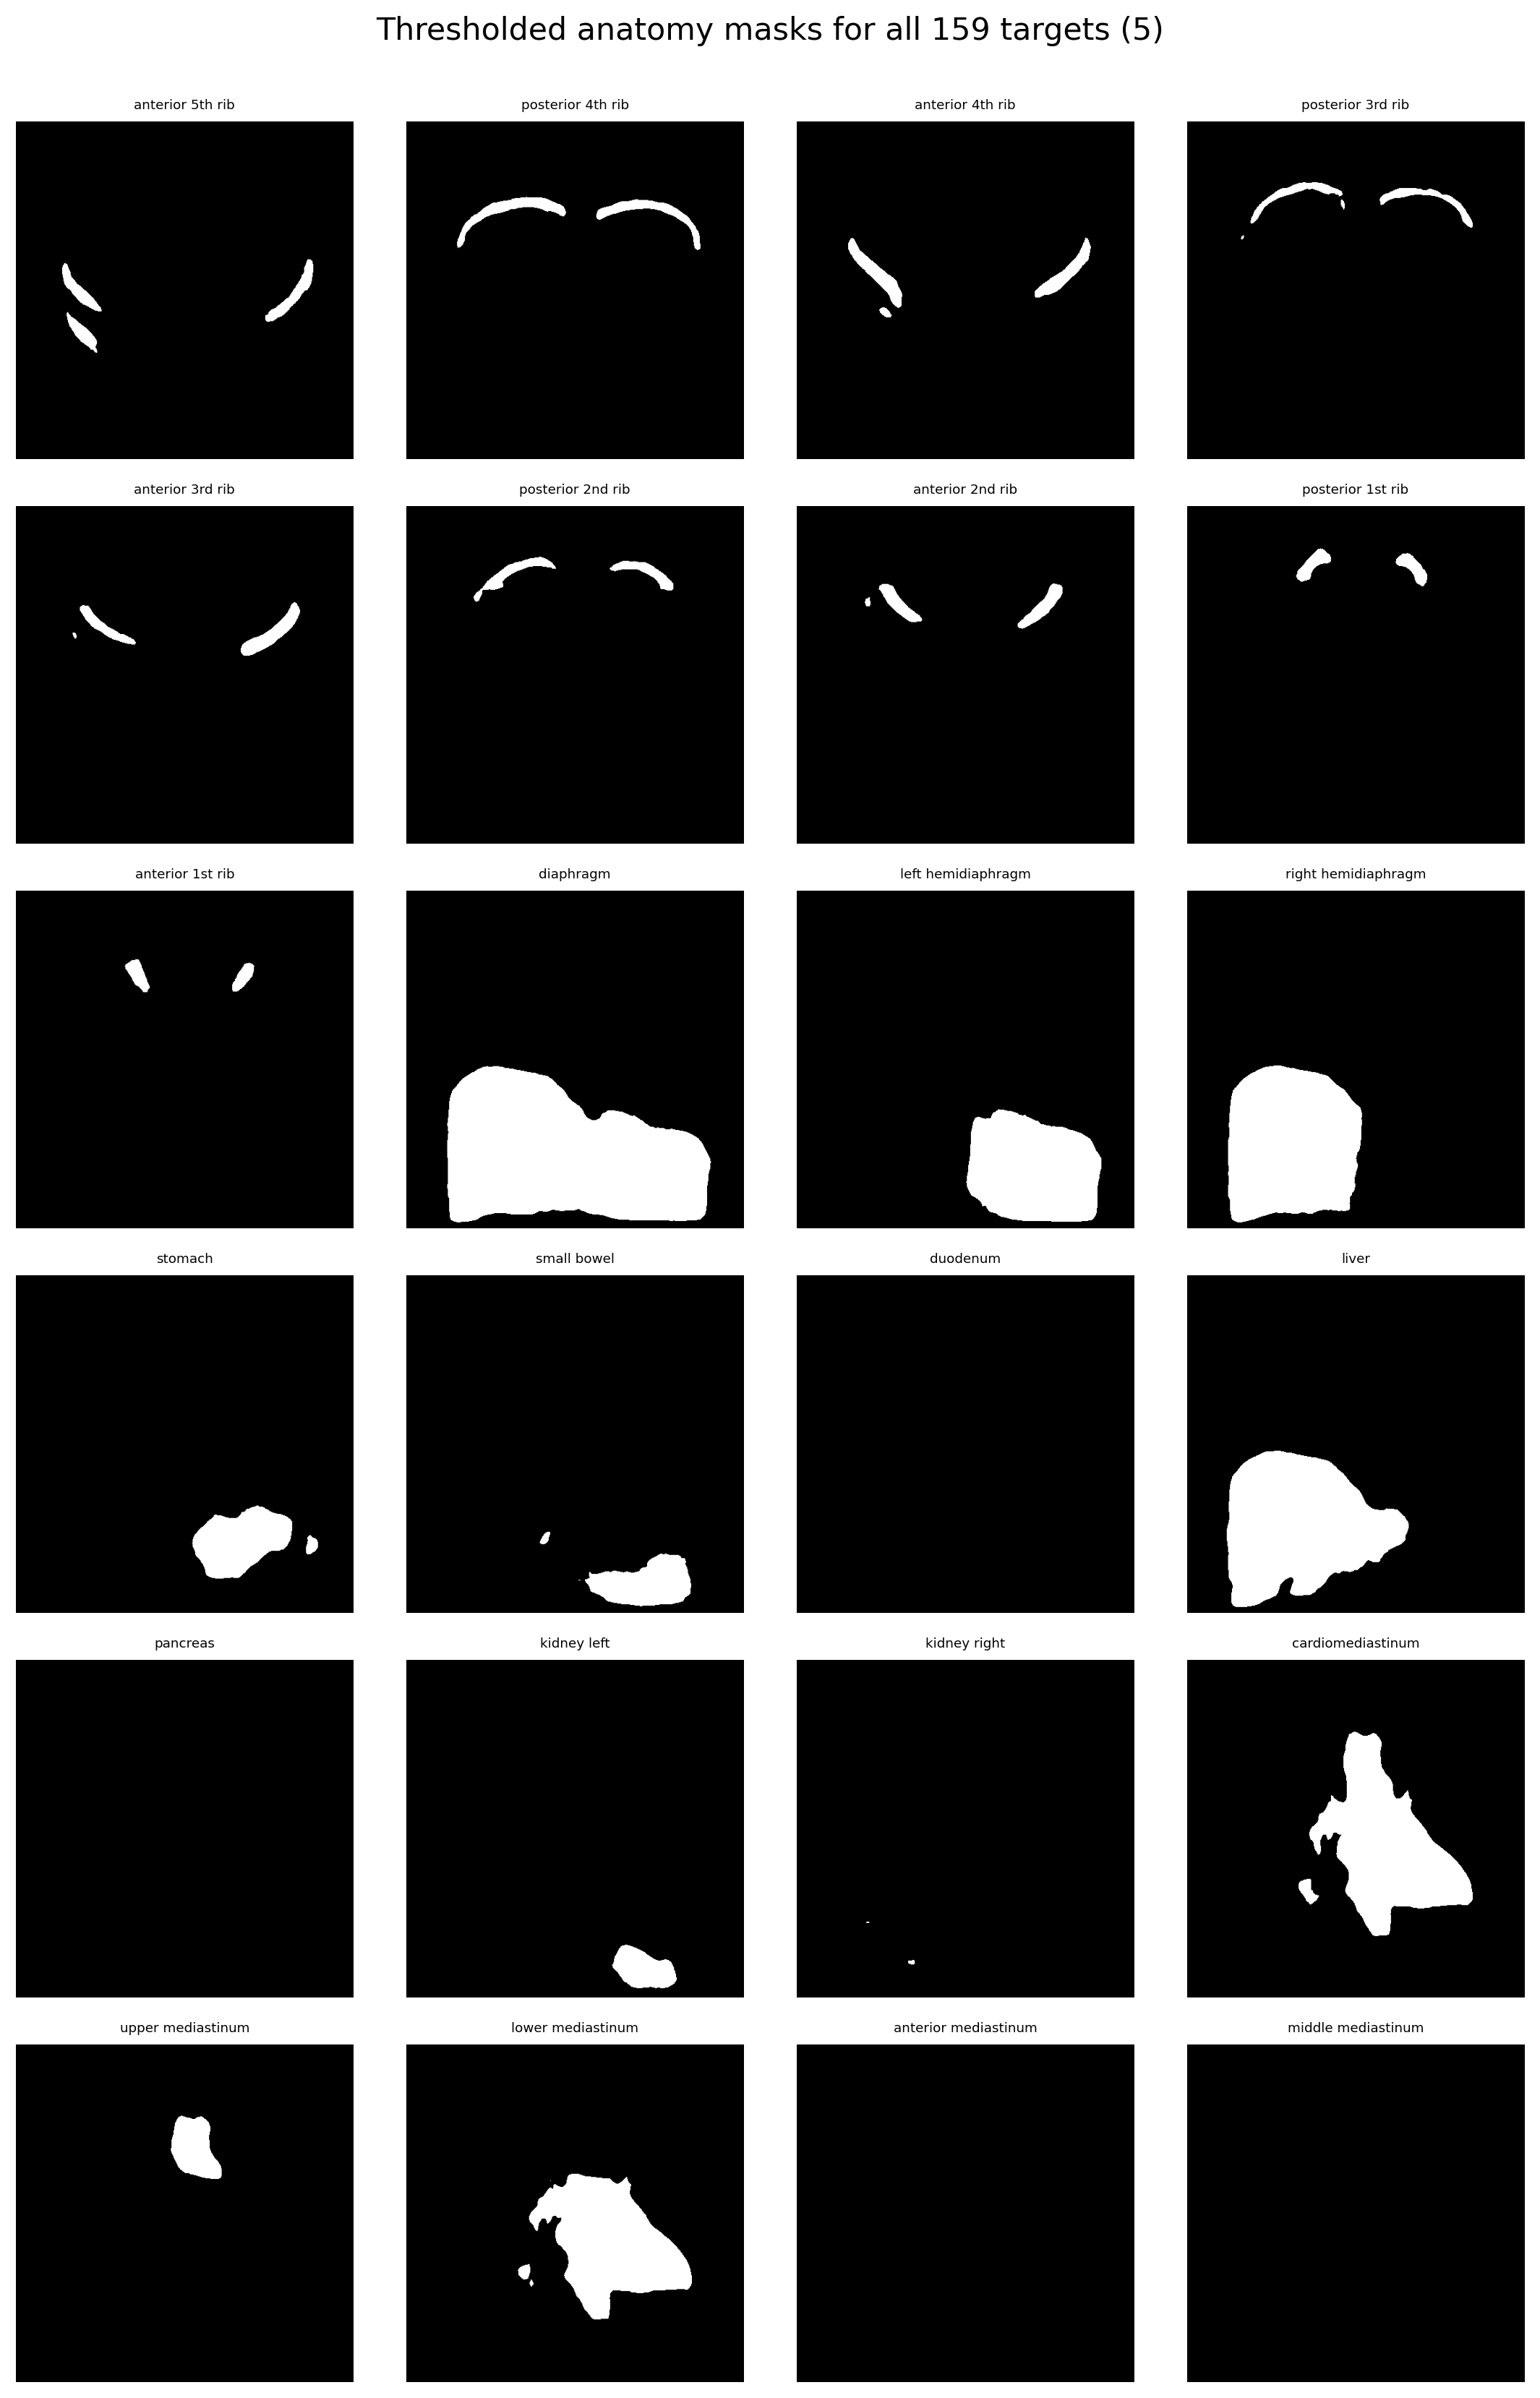

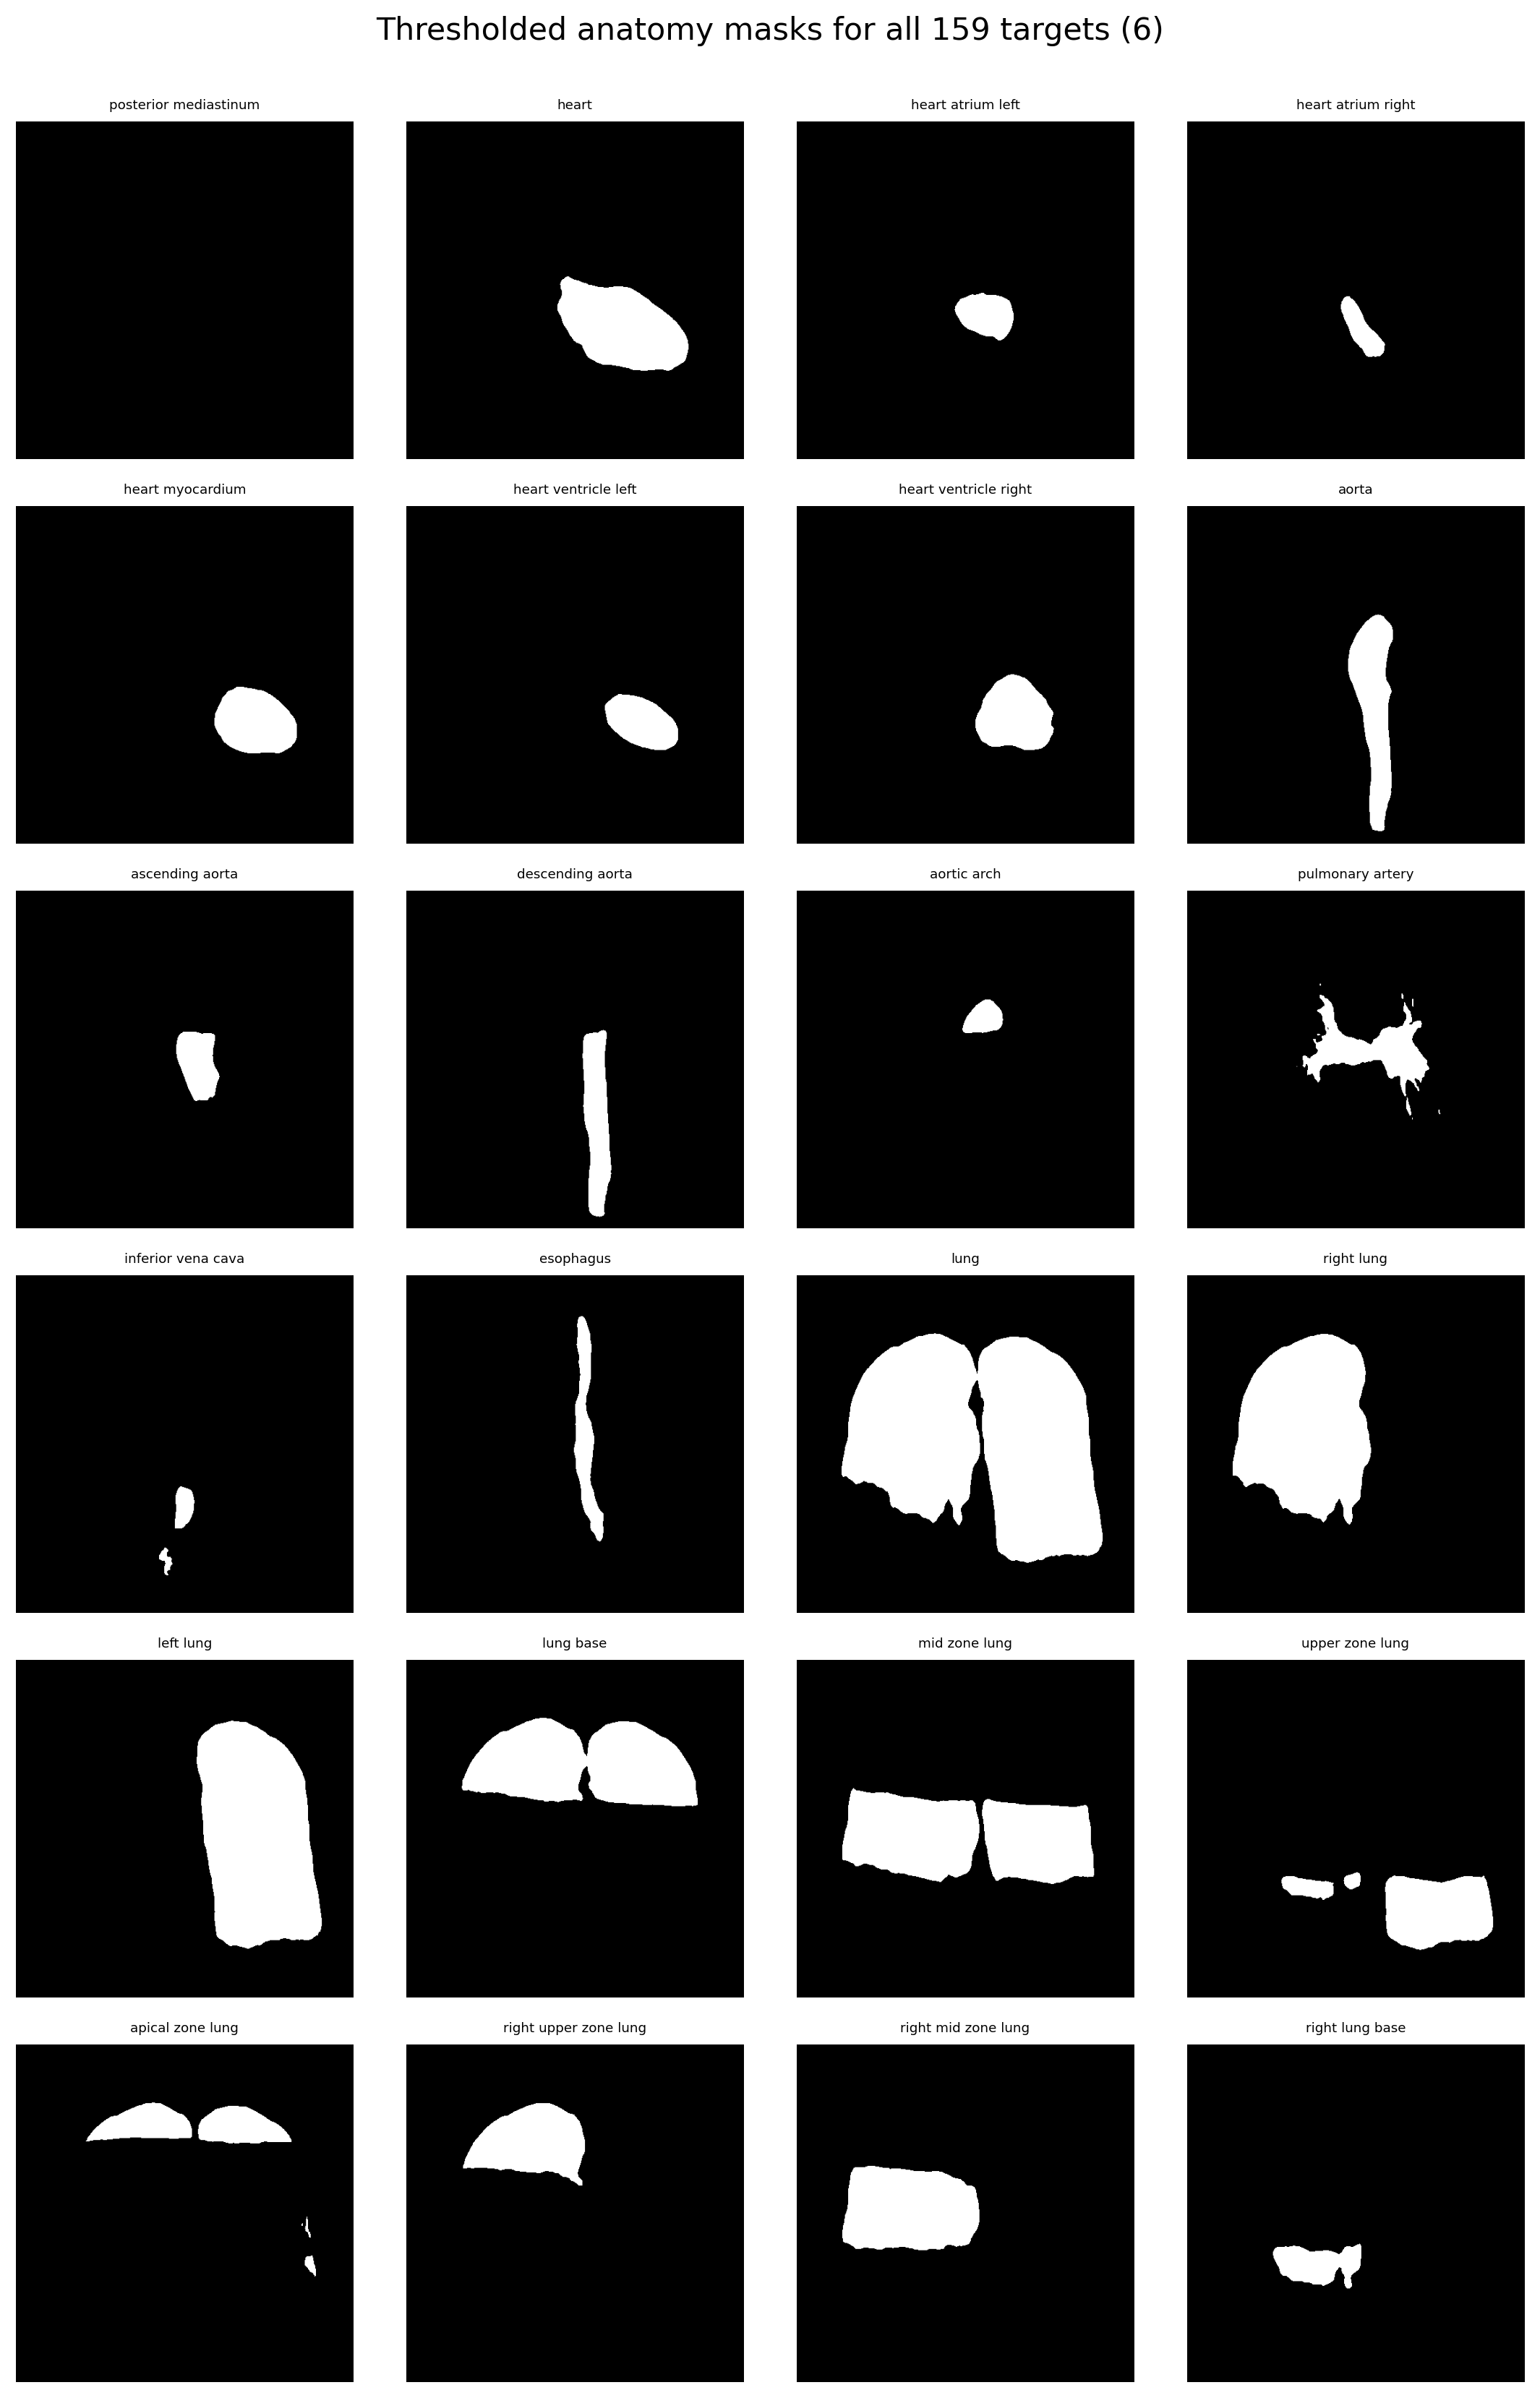

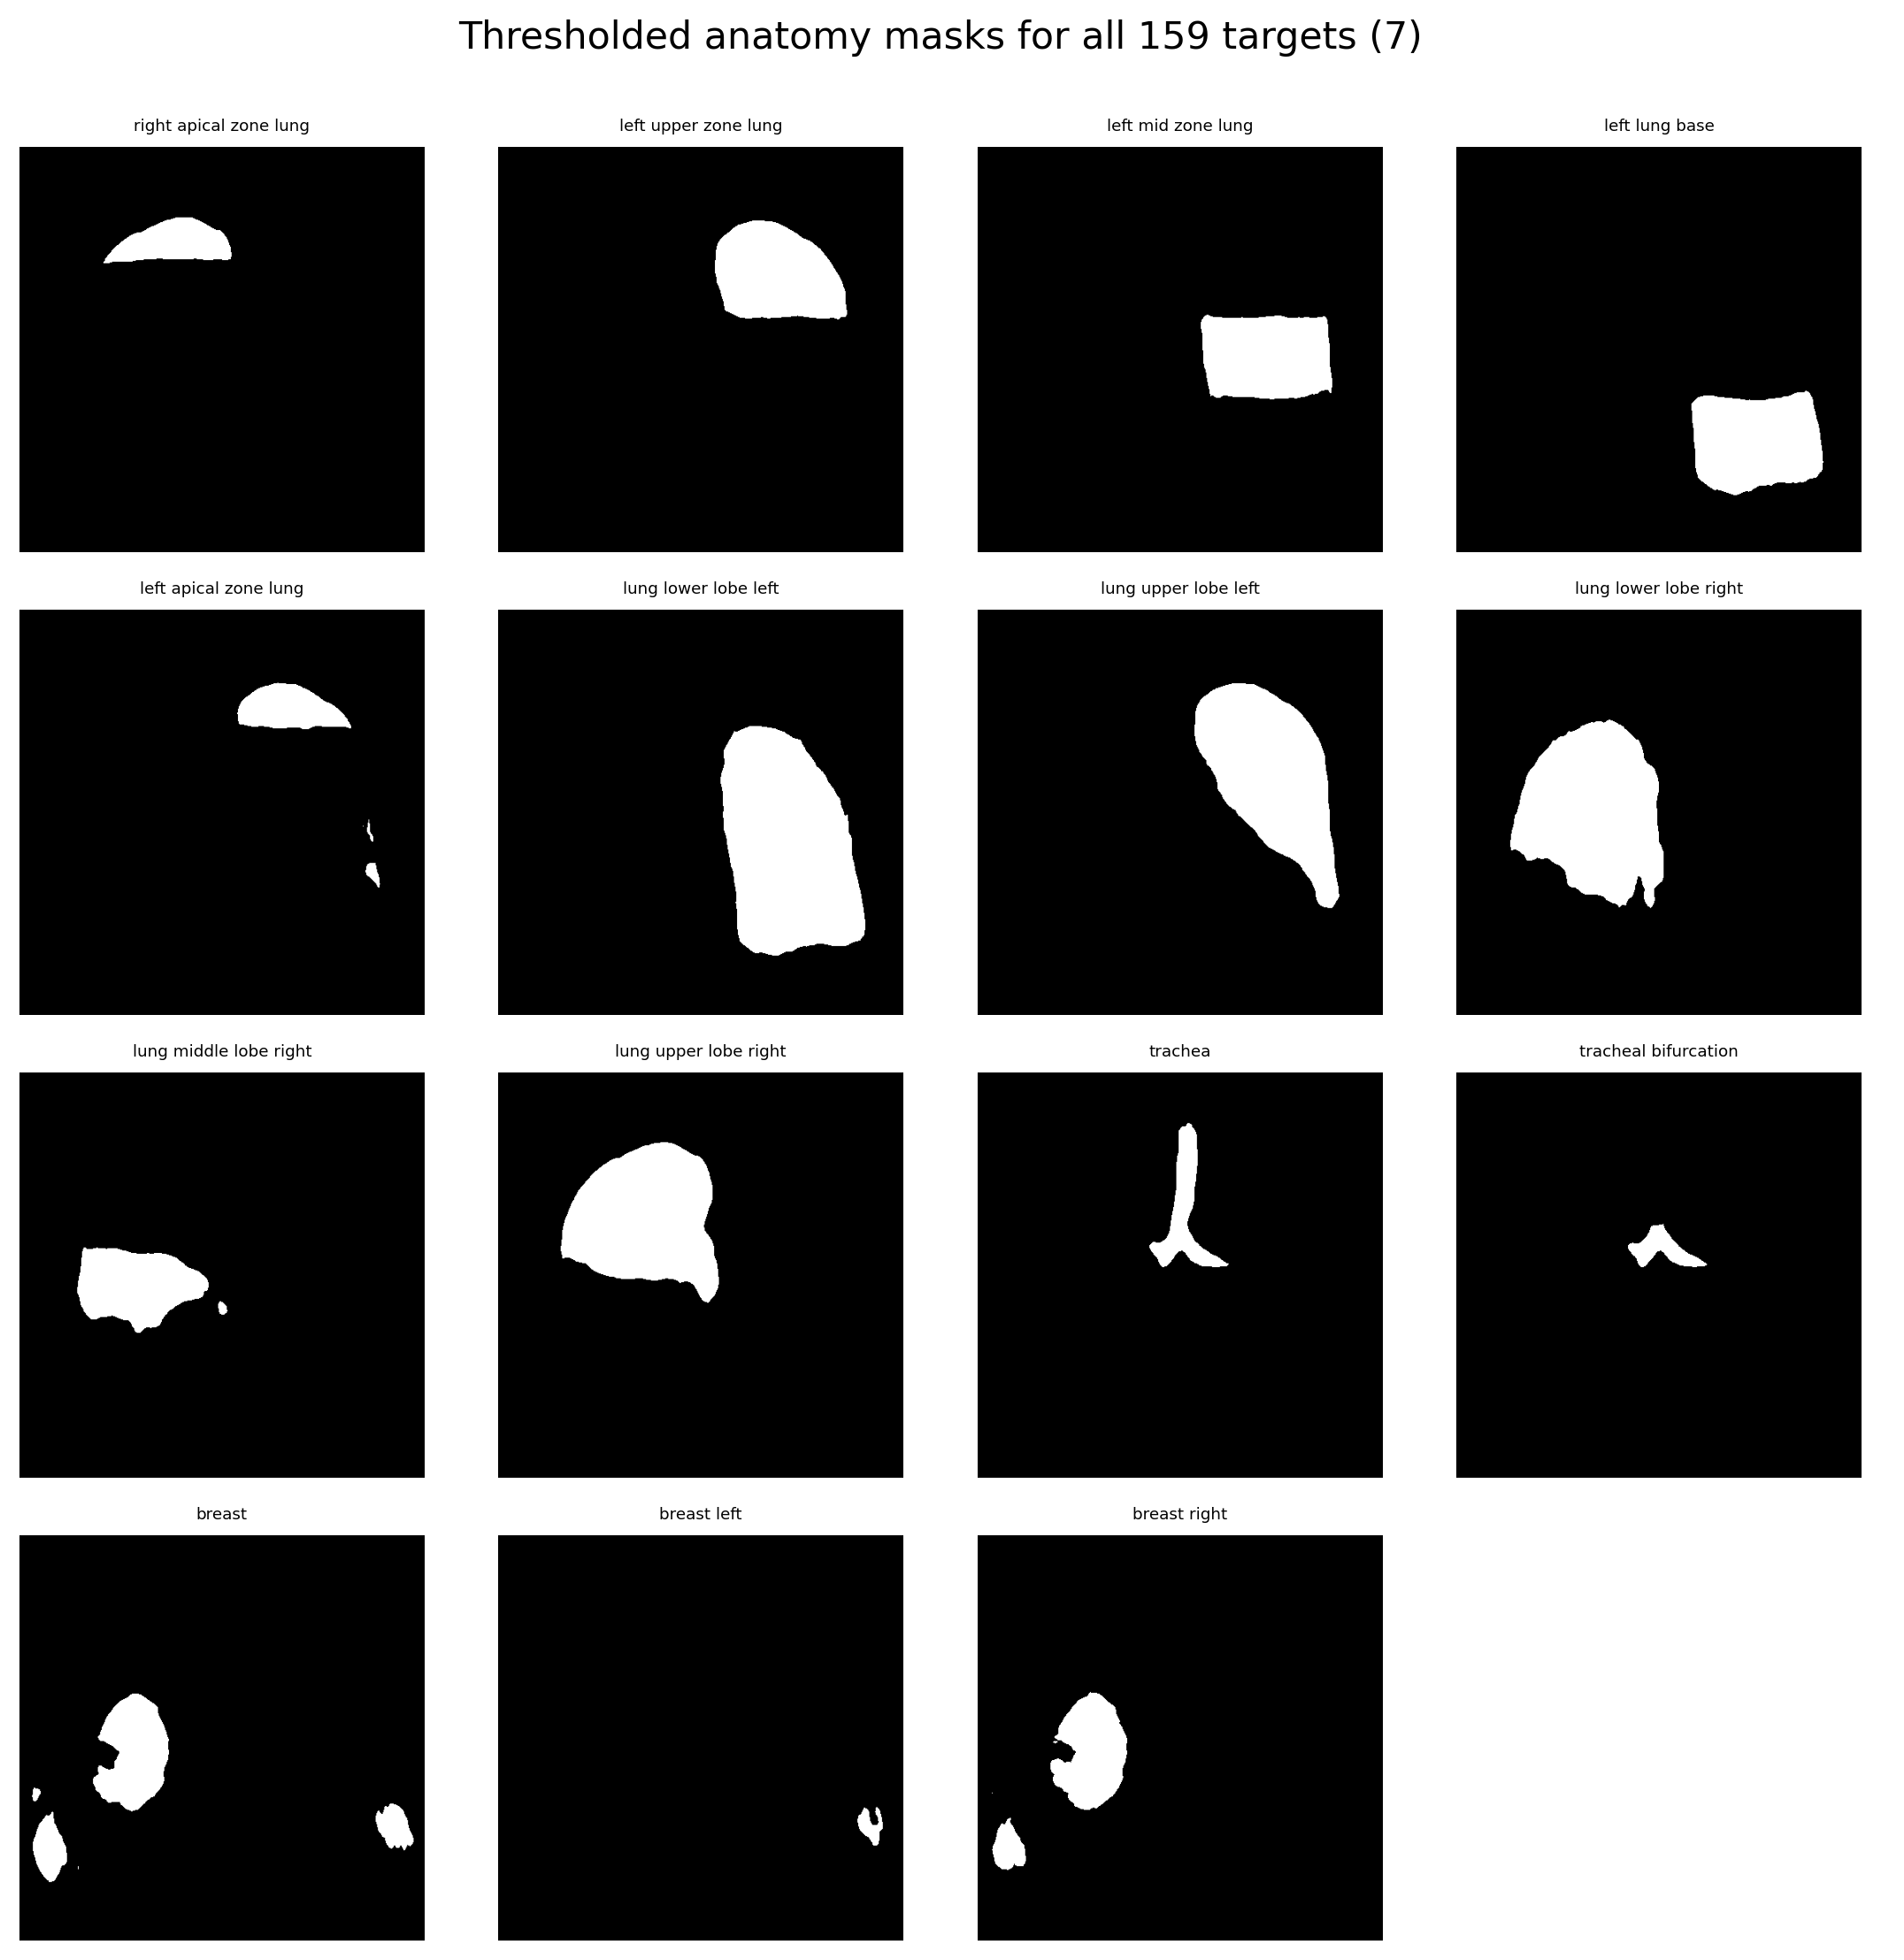

In [9]:
# Thresholded masks.
show_all_targets(
    mask[0],
    title="Thresholded anatomy masks for all 159 targets",
    cmap="gray",
    vmin=0,
    vmax=1,
    threshold=True,
)
